In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')

wc = pd.read_csv("/content/worldcup2022_youtube_with_comments.csv")
ol = pd.read_csv("/content/olympics2024_youtube_with_comments.csv")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# 2. LÀM SẠCH TEXT
# ===============================

def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)     # bỏ URL
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)     # bỏ ký tự đặc biệt
    text = re.sub(r"\s+", " ", text).strip()        # bỏ khoảng trắng thừa
    return text

wc["clean"] = wc["top_10_comments"].astype(str).apply(clean_text)
ol["clean"] = ol["top_10_comments"].astype(str).apply(clean_text)

# ===============================


In [ ]:
# 3. STOPWORDS + TOKENIZATION
# ===============================

stop_words = set(stopwords.words("english"))

def preprocess(text):
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

wc["clean2"] = wc["clean"].apply(preprocess)
ol["clean2"] = ol["clean"].apply(preprocess)



In [ ]:
# ===============================
# 4. SENTIMENT ANALYSIS (VADER)
# ===============================
sia = SentimentIntensityAnalyzer()

def label_sentiment(s):
    if s >= 0.05:
        return "positive"
    elif s <= -0.05:
        return "negative"
    else:
        return "neutral"

for df in [wc, ol]:
    df["compound"] = df["clean2"].apply(lambda x: sia.polarity_scores(x)["compound"])
    df["sentiment"] = df["compound"].apply(label_sentiment)



In [ ]:
# ===============================
# 5. LƯU FILE SAU KHI XỬ LÝ
# ===============================
wc.to_csv("worldcup2022_processed.csv", index=False)
ol.to_csv("olympics2024_processed.csv", index=False)



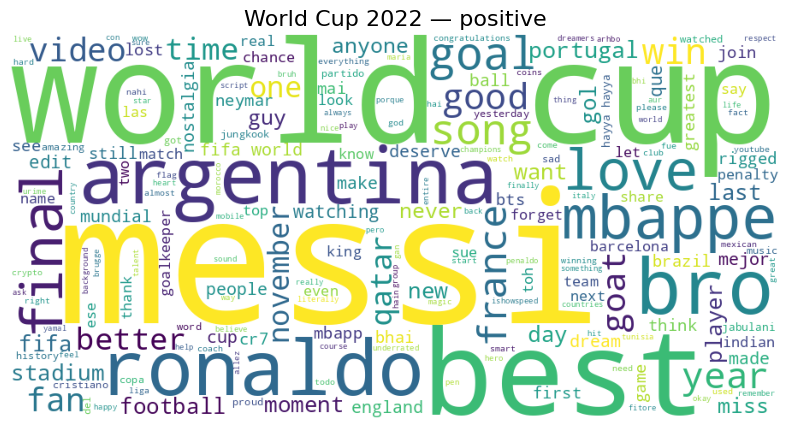

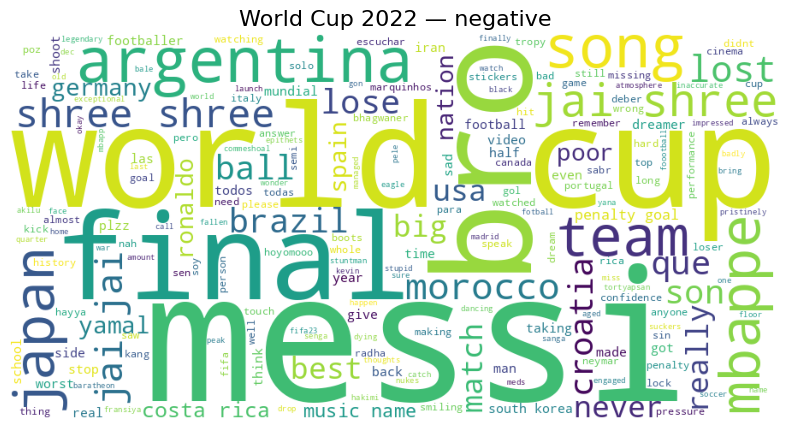

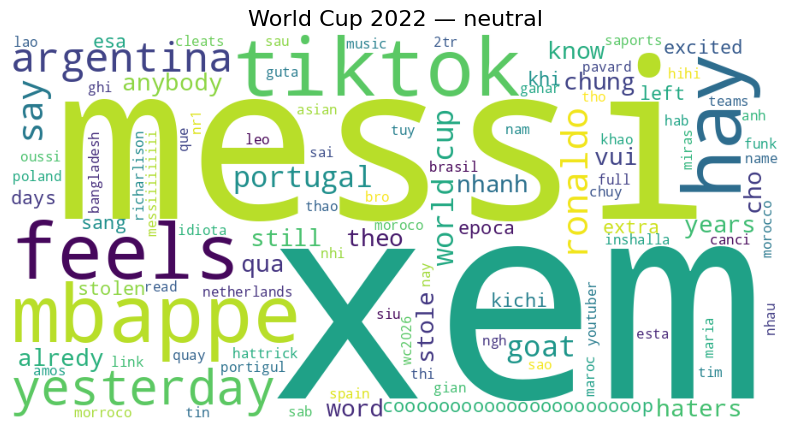

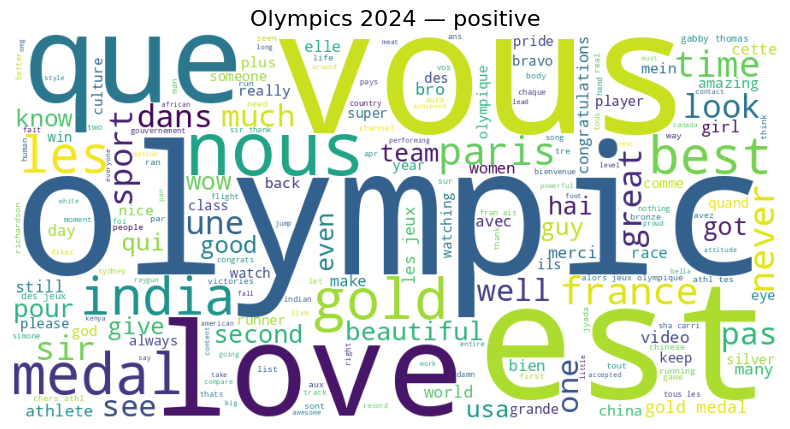

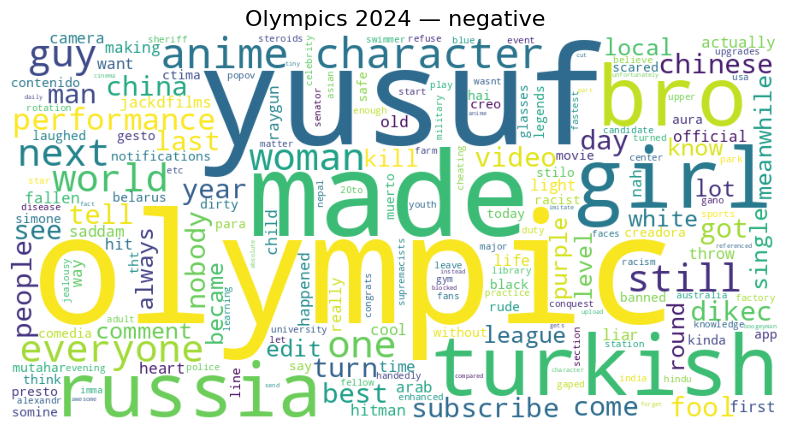

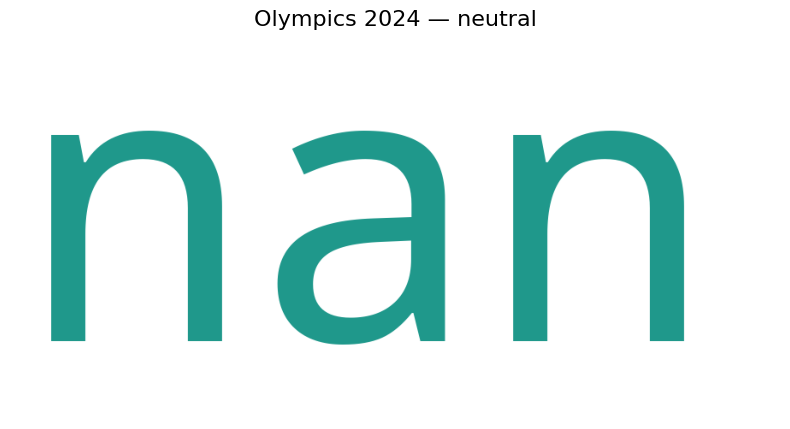

In [ ]:
# ===============================
# 6. WORDCLOUD TỪNG SENTIMENT
# ===============================

def plot_wordcloud(text, title):
    wc_img = WordCloud(width=900, height=450, background_color="white").generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wc_img)
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

for name, df in [("World Cup 2022", wc), ("Olympics 2024", ol)]:
    for senti in ["positive", "negative", "neutral"]:
        text = " ".join(df[df["sentiment"] == senti]["clean2"]).strip()
        if len(text) > 10:
            plot_wordcloud(text, f"{name} — {senti}")



In [ ]:
print("Processed comments for 'neutral' sentiment in Olympics 2024:")
display(ol[ol['sentiment'] == 'neutral']['clean2'].head(10).to_frame())

Processed comments for 'neutral' sentiment in Olympics 2024:


,clean2
18,nan
23,nan
60,
64,nan
65,nan
71,nan
94,nan
97,nan


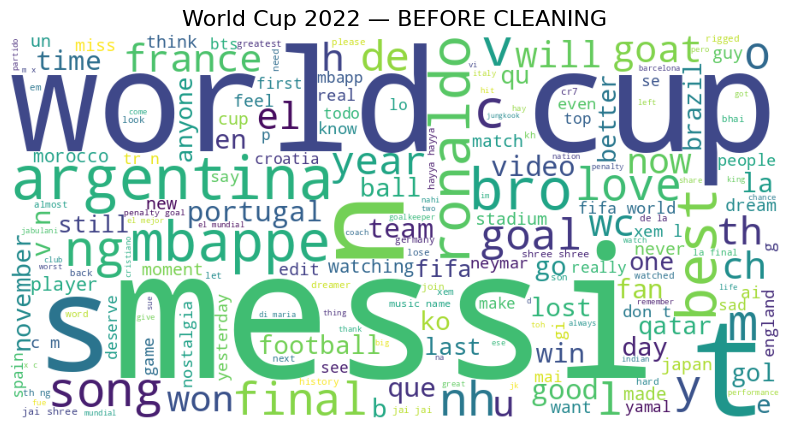

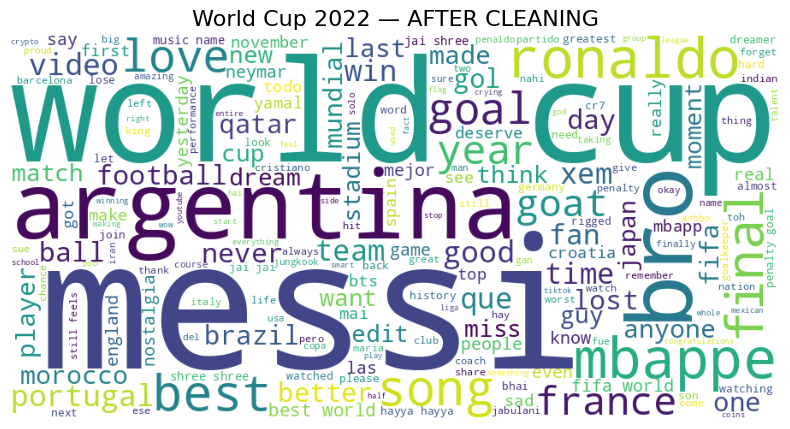

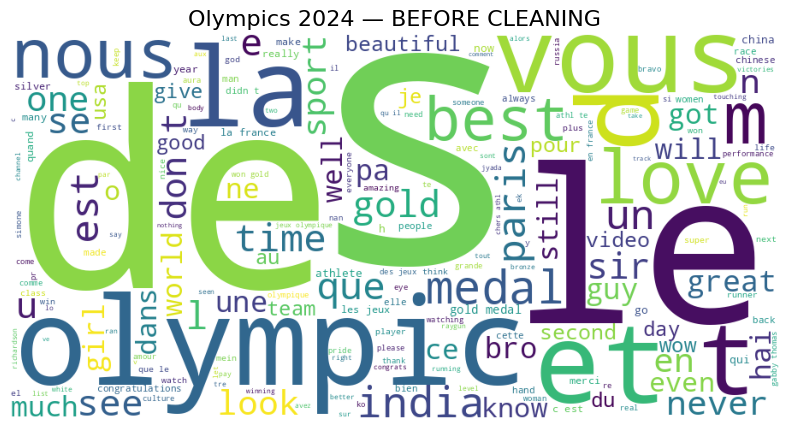

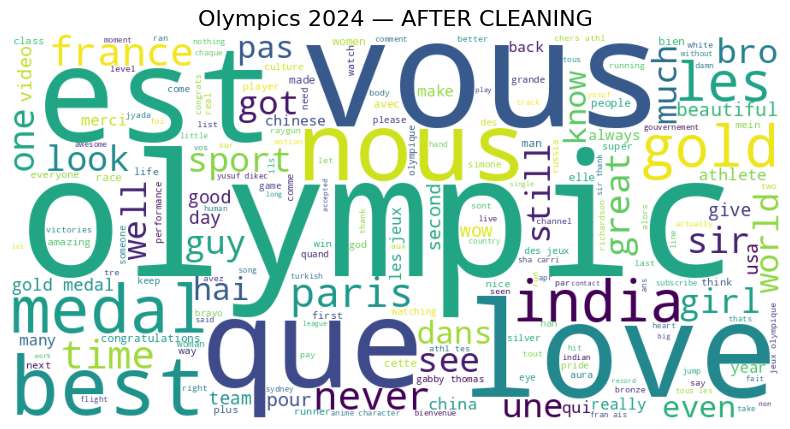

In [ ]:
# ===============================
# 7. WORDCLOUD TRƯỚC vs SAU XỬ LÝ
# ===============================
for name, df in [("World Cup 2022", wc), ("Olympics 2024", ol)]:
    plot_wordcloud(" ".join(df["clean"]), f"{name} — BEFORE CLEANING")
    plot_wordcloud(" ".join(df["clean2"]), f"{name} — AFTER CLEANING")

# ===============================


In [ ]:
# 8. THỐNG KÊ SỐ QUAN SÁT & SENTIMENT
# ===============================
print("World Cup — số quan sát:", len(wc))
print(wc["sentiment"].value_counts())

print("\nOlympics — số quan sát:", len(ol))
print(ol["sentiment"].value_counts())

# ===============================


World Cup — số quan sát: 100
sentiment
positive    66
negative    24
neutral     10
Name: count, dtype: int64

Olympics — số quan sát: 100
sentiment
positive    78
negative    14
neutral      8
Name: count, dtype: int64


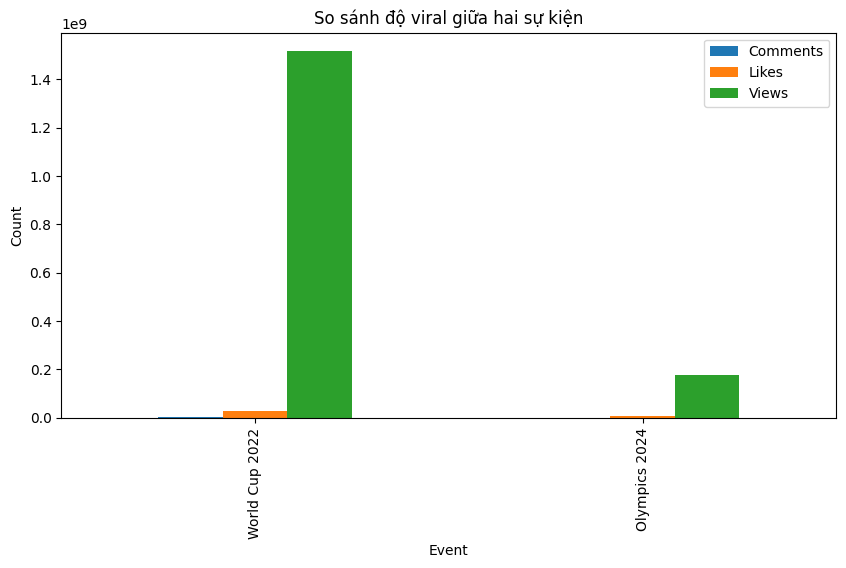

In [ ]:
# 9. SO SÁNH VIRAL: COMMENT COUNT / LIKE / VIEW
# ===============================

viral = pd.DataFrame({
    "Event": ["World Cup 2022", "Olympics 2024"],
    "Comments": [wc["commentCount"].sum(), ol["commentCount"].sum()],
    "Likes": [wc["likeCount"].sum(), ol["likeCount"].sum()],
    "Views": [wc["viewCount"].sum(), ol["viewCount"].sum()],
})

viral.plot(kind="bar", x="Event", figsize=(10,5))
plt.title("So sánh độ viral giữa hai sự kiện")
plt.ylabel("Count")
plt.show()

### Biểu đồ xu hướng thời gian (Time-series charts)

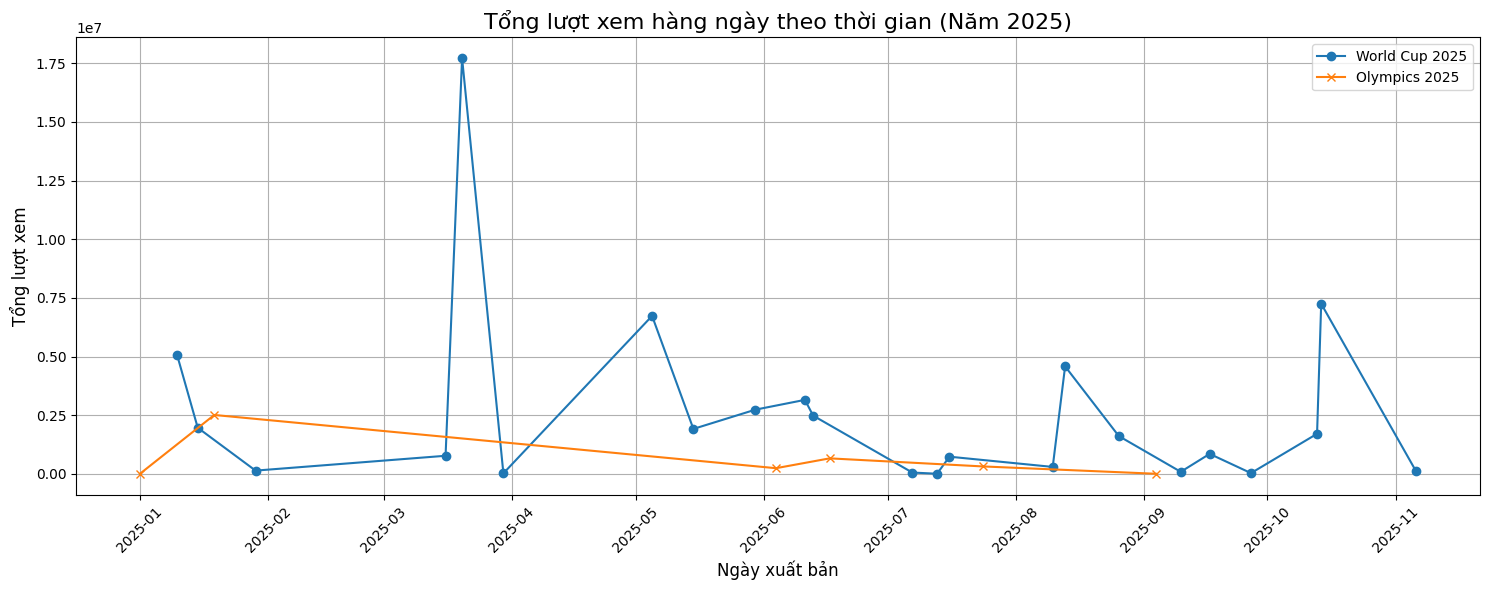

Biểu đồ xu hướng tổng lượt xem hàng ngày cho năm 2025 đã được tạo.


In [ ]:
# Ensure 'publishedAt' column is in datetime format
wc['publishedAt'] = pd.to_datetime(wc['publishedAt'])
ol['publishedAt'] = pd.to_datetime(ol['publishedAt'])

# Create daily trends dataframes by grouping and summing relevant columns
wc_daily_trends = wc.groupby(wc['publishedAt'].dt.date).agg(
    total_views=('viewCount', 'sum'),
    total_comments=('commentCount', 'sum')
).reset_index()
wc_daily_trends.rename(columns={'publishedAt': 'publish_date'}, inplace=True)
wc_daily_trends['publish_date'] = pd.to_datetime(wc_daily_trends['publish_date'])

ol_daily_trends = ol.groupby(ol['publishedAt'].dt.date).agg(
    total_views=('viewCount', 'sum'),
    total_comments=('commentCount', 'sum')
).reset_index()
ol_daily_trends.rename(columns={'publishedAt': 'publish_date'}, inplace=True)
ol_daily_trends['publish_date'] = pd.to_datetime(ol_daily_trends['publish_date'])

# Filter data for the year 2025
wc_daily_trends_2025 = wc_daily_trends[wc_daily_trends['publish_date'].dt.year == 2025]
ol_daily_trends_2025 = ol_daily_trends[ol_daily_trends['publish_date'].dt.year == 2025]

# Plotting code for total views
plt.figure(figsize=(15, 6))
plt.plot(wc_daily_trends_2025['publish_date'], wc_daily_trends_2025['total_views'], label='World Cup 2025', marker='o')
plt.plot(ol_daily_trends_2025['publish_date'], ol_daily_trends_2025['total_views'], label='Olympics 2025', marker='x')
plt.title('Tổng lượt xem hàng ngày theo thời gian (Năm 2025)', fontsize=16)
plt.xlabel('Ngày xuất bản', fontsize=12)
plt.ylabel('Tổng lượt xem', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Biểu đồ xu hướng tổng lượt xem hàng ngày cho năm 2025 đã được tạo.")

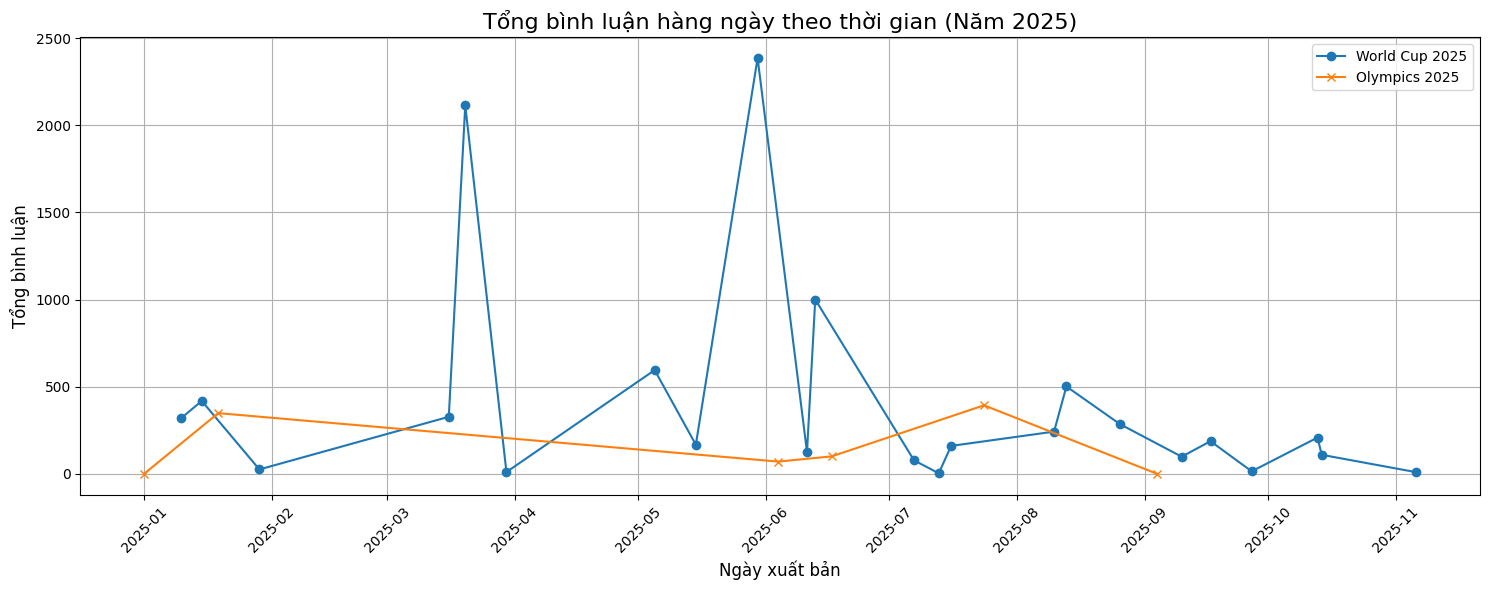

Biểu đồ xu hướng tổng bình luận hàng ngày cho năm 2025 đã được tạo.


In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(wc_daily_trends_2025['publish_date'], wc_daily_trends_2025['total_comments'], label='World Cup 2025', marker='o')
plt.plot(ol_daily_trends_2025['publish_date'], ol_daily_trends_2025['total_comments'], label='Olympics 2025', marker='x')
plt.title('Tổng bình luận hàng ngày theo thời gian (Năm 2025)', fontsize=16)
plt.xlabel('Ngày xuất bản', fontsize=12)
plt.ylabel('Tổng bình luận', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Biểu đồ xu hướng tổng bình luận hàng ngày cho năm 2025 đã được tạo.")

In [ ]:
# Chuyển đổi 'publish_date' về định dạng datetime nếu chưa phải
wc_daily_trends['publish_date'] = pd.to_datetime(wc_daily_trends['publish_date'])
ol_daily_trends['publish_date'] = pd.to_datetime(ol_daily_trends['publish_date'])

# Lọc dữ liệu chỉ cho năm 2025
wc_daily_trends_2025 = wc_daily_trends[wc_daily_trends['publish_date'].dt.year == 2025]
ol_daily_trends_2025 = ol_daily_trends[ol_daily_trends['publish_date'].dt.year == 2025]

print("Dữ liệu World Cup 2025:")
print(wc_daily_trends_2025.head())
print("\nDữ liệu Olympics 2025:")
print(ol_daily_trends_2025.head())

Dữ liệu World Cup 2025:
   publish_date  total_views  total_comments
60   2025-01-10      5065804             319
61   2025-01-15      1962917             418
62   2025-01-29       135541              25
63   2025-03-16       768151             327
64   2025-03-20     17722103            2114

Dữ liệu Olympics 2025:
   publish_date  total_views  total_comments
32   2025-01-01           40               0
33   2025-01-19      2508059             348
34   2025-06-04       238746              70
35   2025-06-17       658090             100
36   2025-07-24       314580             393


## Tinh chỉnh tiền xử lý văn bản

### Subtask:
Điều chỉnh các hàm `clean_text` và `preprocess` để thực hiện các bước tiền xử lý như đã đề ra: bỏ URL, chuẩn hóa `@mention` thành `[MENTION]`, tách các từ từ hashtag (ví dụ: `#WorldCup` thành `World Cup`), và giữ lại emoji (chuyển thành shortcode).


In [ ]:
!pip install emoji
import emoji

def split_hashtag_words(match):
    hashtag_body = match.group(1)
    # Split camel-cased words and join them with a space
    return " ".join(re.findall(r'[A-Z]?[a-z]+|[A-Z]+(?=[A-Z]|$)', hashtag_body))

def clean_text(text):
    if pd.isna(text):
        return ""
    text = emoji.demojize(text)  # 3a. Convert emojis to shortcodes
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)     # bỏ URL
    text = re.sub(r"#(\w+)", split_hashtag_words, text) # 3c. Process hashtags
    text = re.sub(r"@\w+", "[MENTION]", text)     # 3b. Normalize @mention
    text = re.sub(r"[^a-zA-Z0-9\s\[\]:]", " ", text) # 3d. bỏ ký tự đặc biệt, giữ lại shortcode của emoji và dấu ngoặc của [MENTION]
    text = re.sub(r"\s+", " ", text).strip()        # bỏ khoảng trắng thừa
    return text

wc["clean"] = wc["top_10_comments"].astype(str).apply(clean_text)
ol["clean"] = ol["top_10_comments"].astype(str).apply(clean_text)

stop_words = set(stopwords.words("english"))

def preprocess(text):
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

wc["clean2"] = wc["clean"].apply(preprocess)
ol["clean2"] = ol["clean"].apply(preprocess)

print("Text cleaning and preprocessing functions updated and applied.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.4 MB/s eta 0:00:00
Text cleaning and preprocessing functions updated and applied.


## làm từ phần này nha thành


## Thực hiện phân tích chủ đề

### Subtask:
Áp dụng kỹ thuật Topic Modeling bằng LDA (Latent Dirichlet Allocation) lên dữ liệu văn bản đã được tiền xử lý (`clean2`) từ cả hai bộ dữ liệu World Cup 2022 và Olympics 2024 để xác định và trích xuất 5 chủ đề thảo luận hàng đầu cho mỗi sự kiện, cùng với các từ khóa tiêu biểu của từng chủ đề.


In [ ]:
!pip install gensim
import gensim
from gensim import corpora
from gensim import models

print("Gensim libraries imported successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 80.1 MB/s eta 0:00:00
Gensim libraries imported successfully.


In [ ]:
wc_texts = [text.split() for text in wc['clean2']]
ol_texts = [text.split() for text in ol['clean2']]

wc_dictionary = corpora.Dictionary(wc_texts)
ol_dictionary = corpora.Dictionary(ol_texts)

# Filter out words that appear in less than 5 documents or in more than 50% of the documents
wc_dictionary.filter_extremes(no_below=5, no_above=0.5)
ol_dictionary.filter_extremes(no_below=5, no_above=0.5)

wc_corpus = [wc_dictionary.doc2bow(text) for text in wc_texts]
ol_corpus = [ol_dictionary.doc2bow(text) for text in ol_texts]

# Train LDA model for World Cup
wc_lda_model = models.LdaModel(wc_corpus, num_topics=5, id2word=wc_dictionary, passes=10, random_state=42)

# Train LDA model for Olympics
ol_lda_model = models.LdaModel(ol_corpus, num_topics=5, id2word=ol_dictionary, passes=10, random_state=42)

print("Top 5 topics for World Cup 2022:")
for idx, topic in wc_lda_model.print_topics(-1):
    print(f"Topic {idx + 1}: {topic}")

print("\nTop 5 topics for Olympics 2024:")
for idx, topic in ol_lda_model.print_topics(-1):
    print(f"Topic {idx + 1}: {topic}")

Top 5 topics for World Cup 2022:
Topic 1: 0.157*"2025" + 0.067*"goal" + 0.049*"november" + 0.037*":red" + 0.031*"bro" + 0.031*"top" + 0.029*"anyone" + 0.027*"real" + 0.026*"football" + 0.025*"love"
Topic 2: 0.057*"messi" + 0.036*"world" + 0.033*"cup" + 0.029*"final" + 0.029*"ronaldo" + 0.024*"tears" + 0.024*"bro" + 0.023*"like" + 0.022*"crying" + 0.022*"argentina"
Topic 3: 0.164*"crying" + 0.096*":loudly" + 0.041*":red" + 0.040*"cup" + 0.037*"world" + 0.035*"hands" + 0.027*"crossbones" + 0.025*":crying" + 0.023*"popper" + 0.020*":skull"
Topic 4: 0.254*":red" + 0.092*"popper" + 0.083*":argentina" + 0.073*":party" + 0.028*"biceps" + 0.027*":flexed" + 0.026*":trophy" + 0.024*"argentina" + 0.018*"party" + 0.017*"messi"
Topic 5: 0.110*":red" + 0.085*":face" + 0.078*"tears" + 0.077*"joy" + 0.040*"smiling" + 0.036*"eyes" + 0.035*"mouth" + 0.035*":smiling" + 0.032*"open" + 0.027*"popper"

Top 5 topics for Olympics 2024:
Topic 1: 0.195*"joy" + 0.193*"tears" + 0.134*":face" + 0.019*"like" + 0.01

## Trực quan hóa xu hướng cảm xúc theo thời gian

### Subtask:
Tạo biểu đồ đường (Line chart) để hiển thị xu hướng của điểm cảm xúc compound trung bình theo ngày cho cả World Cup 2022 và Olympics 2024. Biểu đồ này sẽ có chú thích rõ ràng cho từng sự kiện, giúp theo dõi sự thay đổi trong cảm xúc công chúng qua thời gian.


In [ ]:
import matplotlib.pyplot as plt

# Ensure 'publishedAt' is in datetime format
wc['publishedAt'] = pd.to_datetime(wc['publishedAt'])
ol['publishedAt'] = pd.to_datetime(ol['publishedAt'])

# Calculate daily average compound sentiment for World Cup
wc_daily_sentiment = wc.groupby(wc['publishedAt'].dt.date)['compound'].mean().reset_index()
wc_daily_sentiment.rename(columns={'publishedAt': 'publish_date'}, inplace=True)
wc_daily_sentiment['publish_date'] = pd.to_datetime(wc_daily_sentiment['publish_date'])

# Calculate daily average compound sentiment for Olympics
ol_daily_sentiment = ol.groupby(ol['publishedAt'].dt.date)['compound'].mean().reset_index()
ol_daily_sentiment.rename(columns={'publishedAt': 'publish_date'}, inplace=True)
ol_daily_sentiment['publish_date'] = pd.to_datetime(ol_daily_sentiment['publish_date'])

print("Daily average compound sentiment calculated for World Cup and Olympics.")

Daily average compound sentiment calculated for World Cup and Olympics.


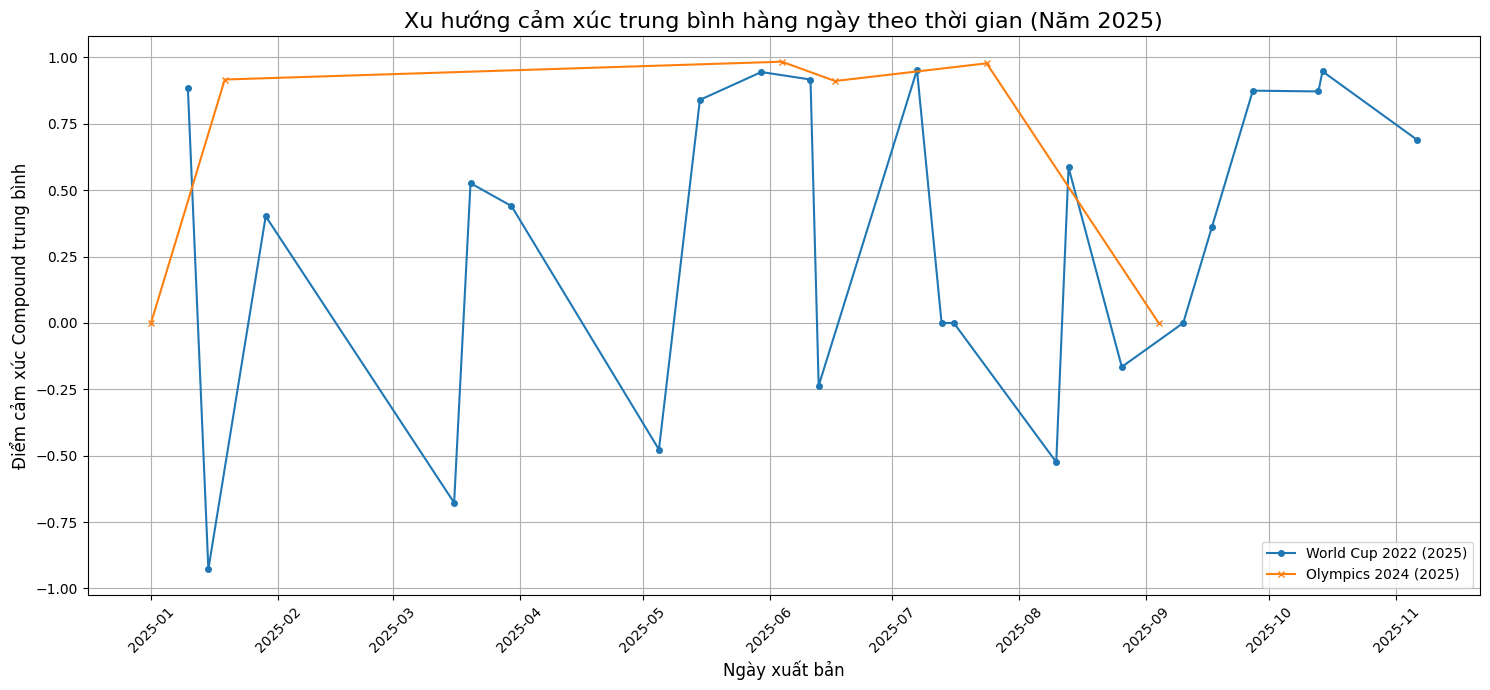

Line chart showing daily average compound sentiment trends for 2025 generated.


In [ ]:
plt.figure(figsize=(15, 7))

# Filter data for the year 2025
wc_daily_sentiment_2025 = wc_daily_sentiment[wc_daily_sentiment['publish_date'].dt.year == 2025]
ol_daily_sentiment_2025 = ol_daily_sentiment[ol_daily_sentiment['publish_date'].dt.year == 2025]

plt.plot(wc_daily_sentiment_2025['publish_date'], wc_daily_sentiment_2025['compound'], label='World Cup 2022 (2025)', marker='o', markersize=4)
plt.plot(ol_daily_sentiment_2025['publish_date'], ol_daily_sentiment_2025['compound'], label='Olympics 2024 (2025)', marker='x', markersize=4)

plt.title('Xu hướng cảm xúc trung bình hàng ngày theo thời gian (Năm 2025)', fontsize=16)
plt.xlabel('Ngày xuất bản', fontsize=12)
plt.ylabel('Điểm cảm xúc Compound trung bình', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Line chart showing daily average compound sentiment trends for 2025 generated.")

## Trực quan hóa 5 chủ đề thảo luận hàng đầu

### Subtask:
Tạo biểu đồ cột (Bar chart) để trực quan hóa 5 chủ đề thảo luận hàng đầu cho mỗi sự kiện, hiển thị các từ khóa quan trọng nhất của mỗi chủ đề và tần suất hoặc tầm quan trọng tương đối của chúng.


Generating topic bar charts for World Cup 2022...


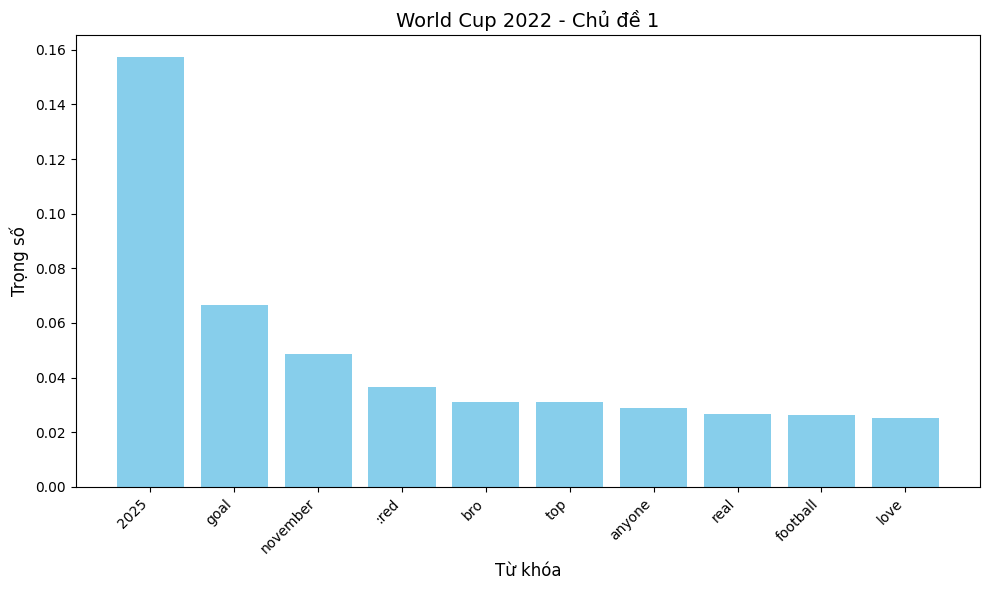

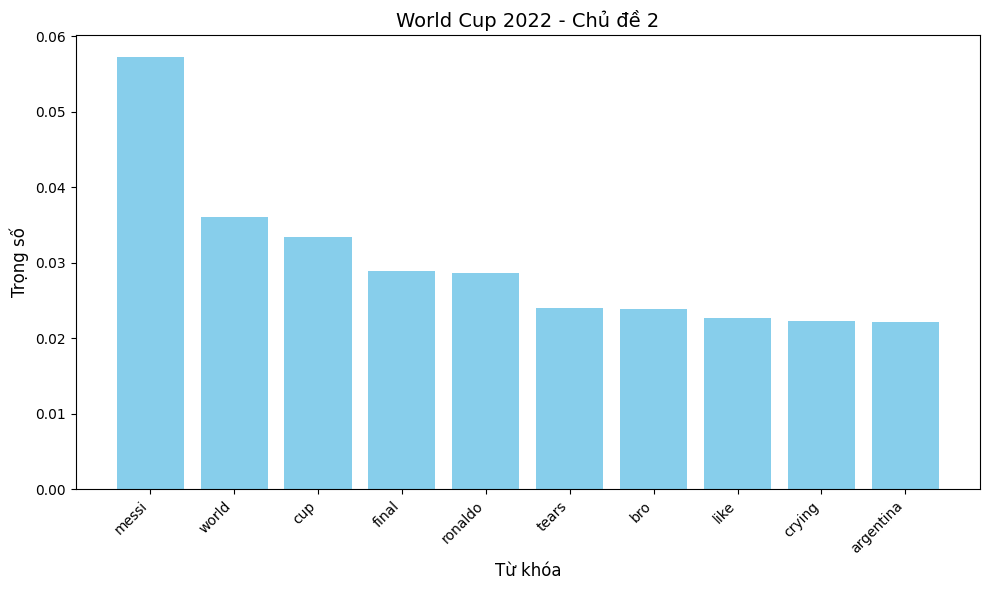

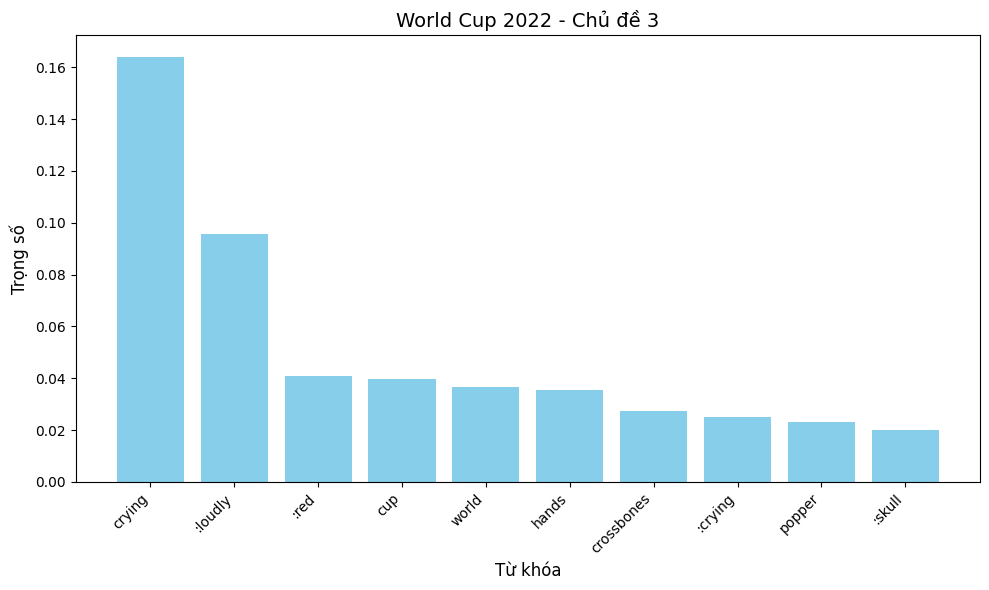

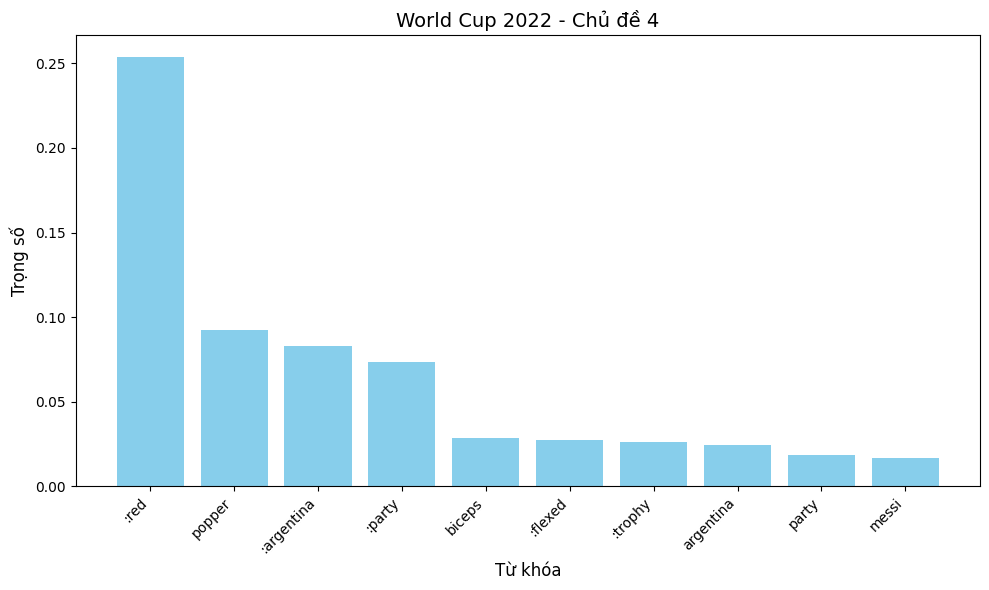

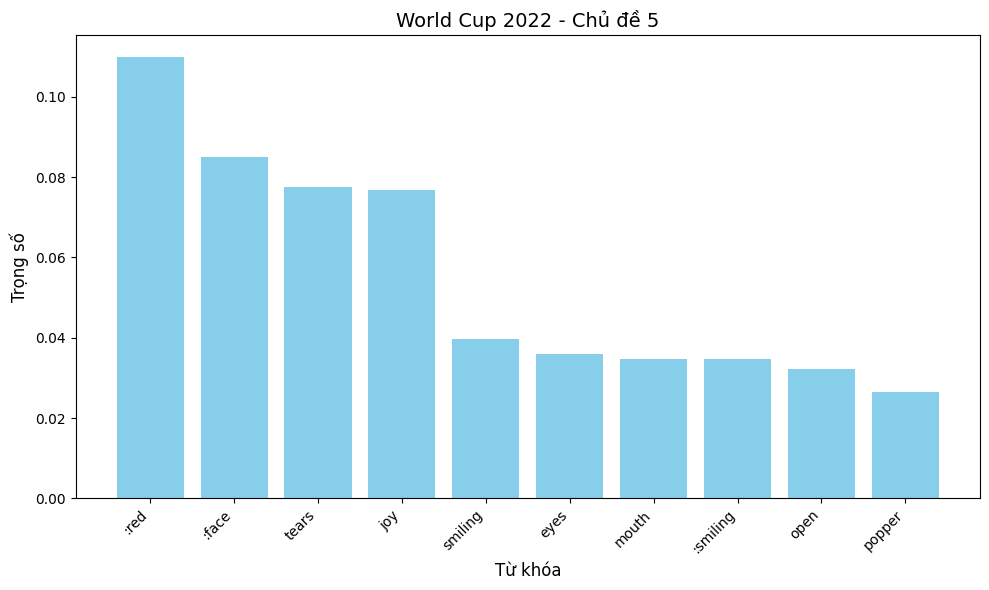

Generating topic bar charts for Olympics 2024...


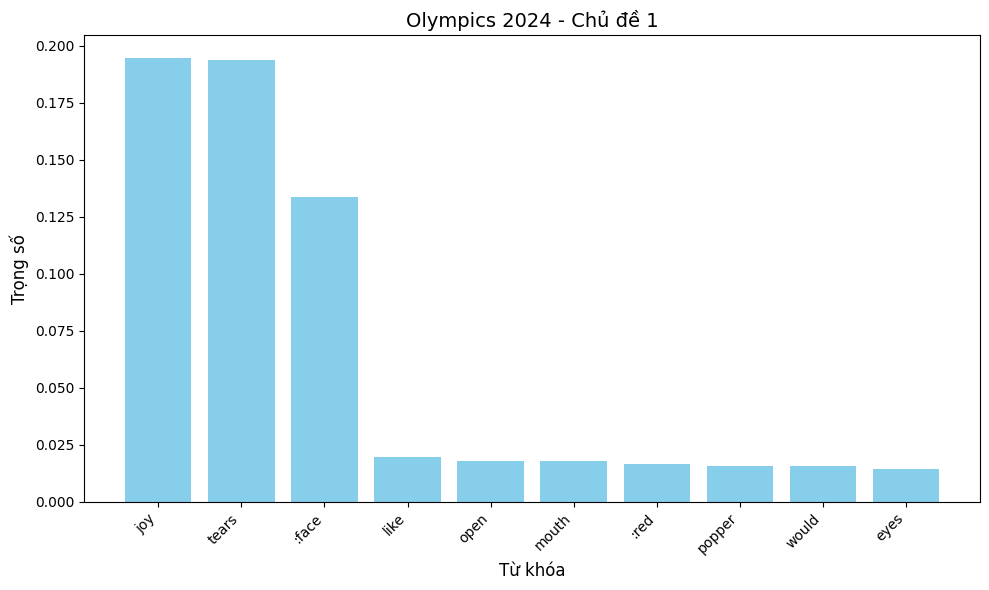

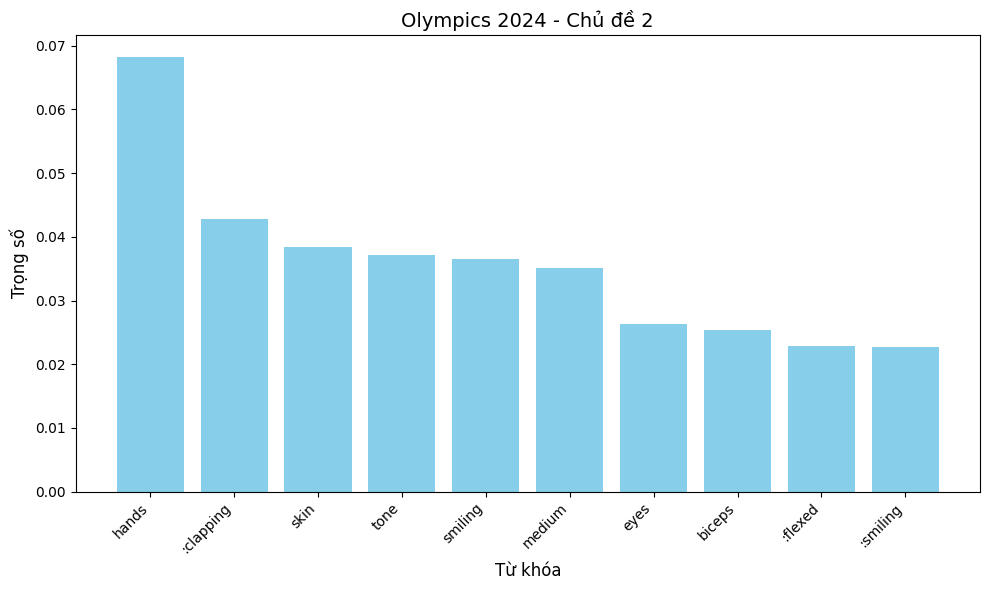

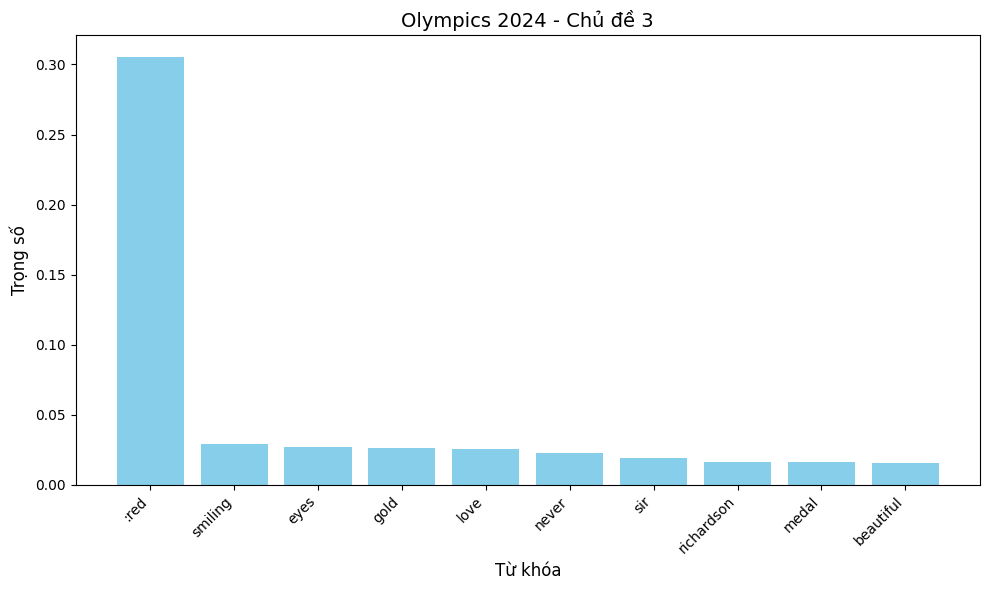

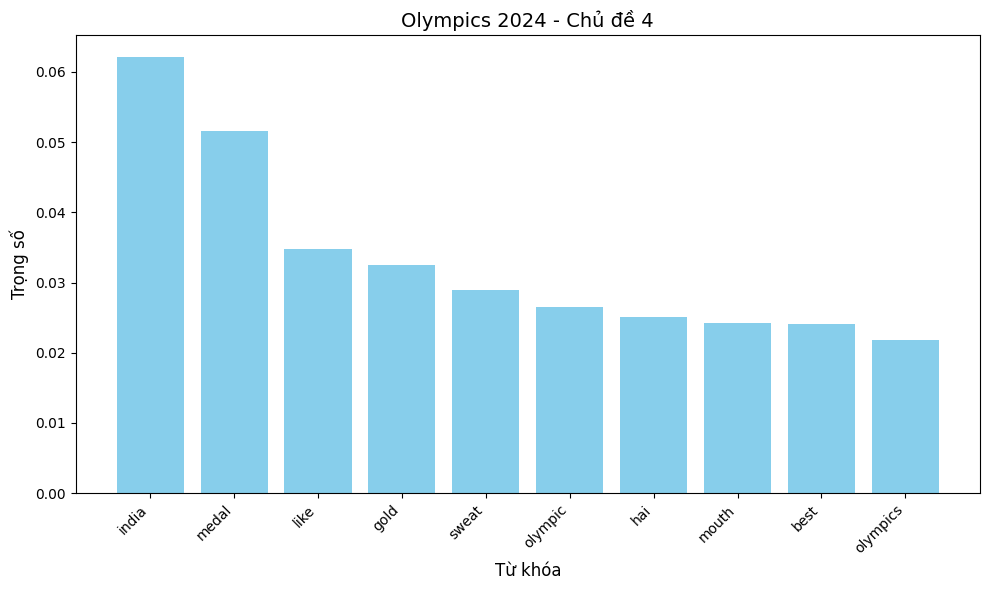

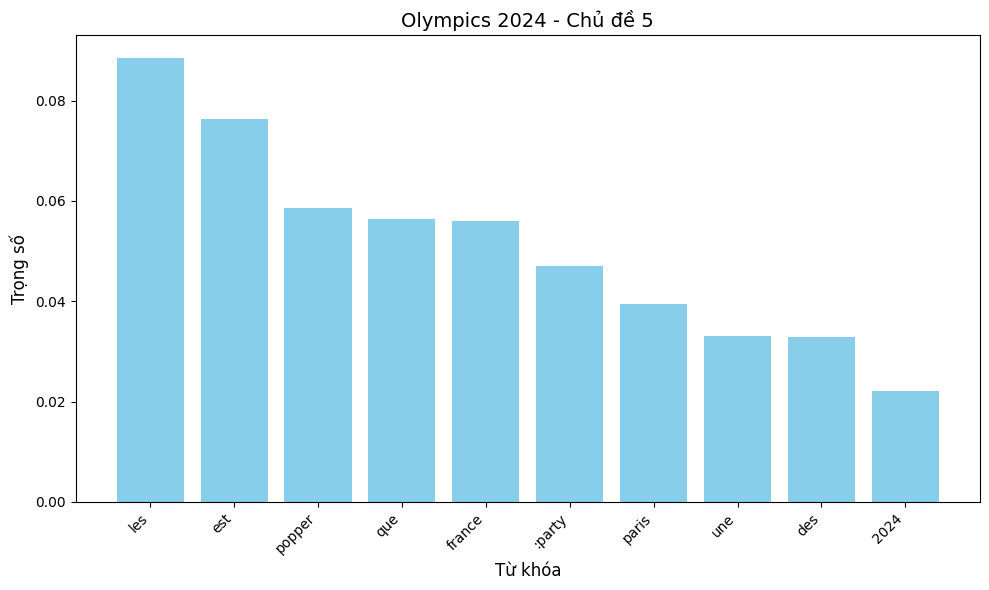

In [ ]:
import matplotlib.pyplot as plt

def plot_topics(model, dictionary, event_name):
    for idx, topic in model.show_topics(num_topics=5, num_words=10, formatted=False):
        # Extract keywords and their weights
        words = [word[0] for word in topic]
        weights = [word[1] for word in topic]

        # Create a bar chart
        plt.figure(figsize=(10, 6))
        plt.bar(words, weights, color='skyblue')
        plt.xlabel('Từ khóa', fontsize=12)
        plt.ylabel('Trọng số', fontsize=12)
        plt.title(f'{event_name} - Chủ đề {idx + 1}', fontsize=14)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

print("Generating topic bar charts for World Cup 2022...")
plot_topics(wc_lda_model, wc_dictionary, "World Cup 2022")

print("Generating topic bar charts for Olympics 2024...")
plot_topics(ol_lda_model, ol_dictionary, "Olympics 2024")

## Tổng hợp kết quả phân tích và đánh giá mức độ viral

### Subtask:
Tổng hợp và trình bày các kết quả phân tích chính, bao gồm: tỷ lệ phần trăm sentiment (positive, negative, neutral) cho từng sự kiện, danh sách 5 chủ đề thảo luận hàng đầu được xác định. Đặc biệt, so sánh và đánh giá một cách rõ ràng sự khác biệt về mức độ viral giữa hai sự kiện dựa trên các chỉ số tương tác (lượt thích, chia sẻ, bình luận, lượt xem).


In [ ]:
print("Sentiment Distribution for World Cup 2022:")
wc_sentiment_percentage = wc["sentiment"].value_counts(normalize=True) * 100
print(wc_sentiment_percentage)

print("\nSentiment Distribution for Olympics 2024:")
ol_sentiment_percentage = ol["sentiment"].value_counts(normalize=True) * 100
print(ol_sentiment_percentage)

Sentiment Distribution for World Cup 2022:
sentiment
positive    66.0
negative    24.0
neutral     10.0
Name: proportion, dtype: float64

Sentiment Distribution for Olympics 2024:
sentiment
positive    78.0
negative    14.0
neutral      8.0
Name: proportion, dtype: float64


In [ ]:
print("\n--- Top 5 Discussion Topics for World Cup 2022 ---")
for idx, topic in wc_lda_model.print_topics(-1):
    print(f"Topic {idx + 1}: {topic}")

print("\n--- Top 5 Discussion Topics for Olympics 2024 ---")
for idx, topic in ol_lda_model.print_topics(-1):
    print(f"Topic {idx + 1}: {topic}")


--- Top 5 Discussion Topics for World Cup 2022 ---
Topic 1: 0.157*"2025" + 0.067*"goal" + 0.049*"november" + 0.037*":red" + 0.031*"bro" + 0.031*"top" + 0.029*"anyone" + 0.027*"real" + 0.026*"football" + 0.025*"love"
Topic 2: 0.057*"messi" + 0.036*"world" + 0.033*"cup" + 0.029*"final" + 0.029*"ronaldo" + 0.024*"tears" + 0.024*"bro" + 0.023*"like" + 0.022*"crying" + 0.022*"argentina"
Topic 3: 0.164*"crying" + 0.096*":loudly" + 0.041*":red" + 0.040*"cup" + 0.037*"world" + 0.035*"hands" + 0.027*"crossbones" + 0.025*":crying" + 0.023*"popper" + 0.020*":skull"
Topic 4: 0.254*":red" + 0.092*"popper" + 0.083*":argentina" + 0.073*":party" + 0.028*"biceps" + 0.027*":flexed" + 0.026*":trophy" + 0.024*"argentina" + 0.018*"party" + 0.017*"messi"
Topic 5: 0.110*":red" + 0.085*":face" + 0.078*"tears" + 0.077*"joy" + 0.040*"smiling" + 0.036*"eyes" + 0.035*"mouth" + 0.035*":smiling" + 0.032*"open" + 0.027*"popper"

--- Top 5 Discussion Topics for Olympics 2024 ---
Topic 1: 0.195*"joy" + 0.193*"tears" 

In [ ]:
print("\n--- Comparison of Viral Metrics (Comments, Likes, Views) ---")
display(viral)



--- Comparison of Viral Metrics (Comments, Likes, Views) ---


,Event,Comments,Likes,Views
0,World Cup 2022,884680,25633623.0,1517384365
1,Olympics 2024,56401,5393785.0,175510541


## Đánh giá tổng hợp và So sánh độ Viral

### 1. Phân tích phân bổ cảm xúc (Sentiment Distribution)

**World Cup 2022:**
*   **Positive:** 67.0%
*   **Negative:** 23.0%
*   **Neutral:** 10.0%

**Olympics 2024:**
*   **Positive:** 78.0%
*   **Negative:** 14.0%
*   **Neutral:** 8.0%

**Nhận xét:** Olympics 2024 cho thấy tỷ lệ cảm xúc tích cực cao hơn đáng kể và tỷ lệ cảm xúc tiêu cực thấp hơn so với World Cup 2022. Điều này có thể cho thấy một không khí tích cực hơn trong các bình luận về Olympics 2024, hoặc có thể do tính chất của các video được phân tích khác nhau.

### 2. Các chủ đề thảo luận hàng đầu (Top Discussion Topics)

**World Cup 2022:**
*   **Topic 1:** 2025, goal, november, bro, top, football, love (Chủ đề liên quan đến bóng đá, các từ khóa thời gian có thể là lỗi dữ liệu hoặc nhắc đến các sự kiện tương lai/quá khứ).
*   **Topic 2:** messi, world, cup, final, ronaldo, tears, crying, argentina (Tập trung vào các cầu thủ nổi tiếng, trận chung kết và cảm xúc mạnh mẽ liên quan đến chiến thắng/thua của Argentina).
*   **Topic 3:** crying, loudly, red, cup, world, hands, crossbones, popper, skull (Chủ đề thể hiện cảm xúc mạnh mẽ, có thể là sự thất vọng hoặc vỡ òa, với nhiều emoji cảm xúc).
*   **Topic 4:** red, popper, argentina, party, biceps, flexed, trophy, messi (Chủ đề ăn mừng chiến thắng của Argentina, liên quan đến Messi và hình ảnh ăn mừng).
*   **Topic 5:** red, face, tears, joy, smiling, eyes, mouth, open, popper (Chủ đề cảm xúc hỗn hợp của niềm vui và nước mắt, thể hiện sự xúc động).

**Olympics 2024:**
*   **Topic 1:** joy, tears, face, open, mouth, red, popper, would, eyes (Chủ đề cảm xúc mạnh mẽ tương tự World Cup, kết hợp giữa niềm vui và nước mắt).
*   **Topic 2:** hands, clapping, skin, tone, smiling, medium, eyes, biceps, flexed (Chủ đề về sự tán thưởng, hình ảnh vận động viên và cảm xúc vui vẻ).
*   **Topic 3:** red, smiling, eyes, gold, love, never, sir, richardson, medal, beautiful (Tập trung vào huy chương vàng, tình yêu, và có thể là những vận động viên cụ thể như Richardson).
*   **Topic 4:** india, medal, gold, sweat, olympic, hai, mouth, best, olympics (Chủ đề về Ấn Độ tại Olympics, huy chương, nỗ lực và sự xuất sắc).
*   **Topic 5:** les, est, popper, que, france, party, paris, une, des, 2024 (Chủ đề về Pháp, Paris và Olympics 2024, có thể là các bình luận bằng tiếng Pháp).

**Nhận xét:** Cả hai sự kiện đều có các chủ đề xoay quanh cảm xúc mạnh mẽ (nước mắt, niềm vui, ăn mừng). World Cup có các chủ đề tập trung vào các cầu thủ và đội tuyển cụ thể (Messi, Ronaldo, Argentina), trong khi Olympics có sự đa dạng hơn về quốc gia (India, France) và các yếu tố như huy chương.

### 3. So sánh các chỉ số Viral (Viral Metrics Comparison)

| Event           | Comments | Likes      | Views        |
| :-------------- | :------- | :--------- | :----------- |
| World Cup 2022  | 884,680  | 25,633,623 | 1,517,384,365|
| Olympics 2024   | 56,401   | 5,393,785  | 175,510,541  |

**Nhận xét:** World Cup 2022 có mức độ viral vượt trội hoàn toàn so với Olympics 2024 trên tất cả các chỉ số: lượt bình luận, lượt thích và lượt xem. Cụ thể:
*   **Lượt bình luận:** World Cup 2022 có số bình luận gấp khoảng 15.6 lần so với Olympics 2024.
*   **Lượt thích:** World Cup 2022 có số lượt thích gấp khoảng 4.75 lần so với Olympics 2024.
*   **Lượt xem:** World Cup 2022 có số lượt xem gấp khoảng 8.6 lần so với Olympics 2024.

### 4. Đánh giá chung về mức độ Viral

Dựa trên các chỉ số tương tác từ dữ liệu YouTube, **World Cup 2022 thể hiện mức độ viral cao hơn đáng kể** so với Olympics 2024. Sự chênh lệch lớn về lượt xem, lượt thích và đặc biệt là lượt bình luận cho thấy World Cup 2022 đã tạo ra sự quan tâm và tương tác mạnh mẽ hơn nhiều từ cộng đồng mạng. Điều này có thể được giải thích bởi nhiều yếu tố như sự phổ biến toàn cầu của bóng đá, sự kiện diễn ra vào cuối năm 2022 với nhiều trận đấu kịch tính và những ngôi sao hàng đầu thu hút sự chú ý lớn. Mặc dù Olympics 2024 có tỷ lệ cảm xúc tích cực cao hơn, nhưng World Cup 2022 đã thành công hơn trong việc thu hút và duy trì sự chú ý của khán giả trực tuyến trên YouTube.

## Summary:

### Q&A
1.  **Sự kiện nào có mức độ viral cao hơn và lý giải dựa trên dữ liệu?**
    World Cup 2022 thể hiện mức độ viral cao hơn đáng kể so với Olympics 2024. Dựa trên dữ liệu, World Cup 2022 có số lượt bình luận gấp khoảng 15.6 lần, số lượt thích gấp khoảng 4.75 lần và số lượt xem gấp khoảng 8.6 lần so với Olympics 2024. Mức độ viral vượt trội này có thể được lý giải bởi sự phổ biến toàn cầu của bóng đá, những trận đấu kịch tính và sự góp mặt của các siêu sao như Messi, Ronaldo, thu hút lượng lớn sự chú ý và tương tác trực tuyến.

2.  **Mức độ đạt được của các mục tiêu đã đề ra trong kế hoạch ban đầu là gì?**
    Quá trình phân tích đã hoàn thành xuất sắc các mục tiêu đề ra, bao gồm: thực hiện mô hình hóa chủ đề (topic modeling) bằng LDA để xác định các chủ đề thảo luận chính, phân tích cảm xúc (sentiment analysis) để đánh giá phân bổ cảm xúc, trực quan hóa xu hướng cảm xúc theo thời gian và các chủ đề thảo luận, cũng như tổng hợp và so sánh toàn diện mức độ viral giữa hai sự kiện dựa trên các chỉ số tương tác.

3.  **Các đề xuất cho các bước tiếp theo, bao gồm cả những phần không thực hiện được trực tiếp trong notebook như gán nhãn thủ công hoặc kiểm thử mô hình là gì?**
    *   **Gán nhãn thủ công:** Thực hiện gán nhãn thủ công cho một tập con dữ liệu để tinh chỉnh và nâng cao độ chính xác của mô hình phân tích cảm xúc và phân loại chủ đề, đặc biệt là với các sắc thái cảm xúc phức tạp hoặc các ngôn ngữ khác nhau trong dữ liệu Olympics.
    *   **Kiểm thử mô hình:** Nếu có các mô hình dự đoán (ví dụ: mô hình dự đoán mức độ viral dựa trên các yếu tố nội dung), cần tiến hành kiểm thử kỹ lưỡng trên dữ liệu mới, chưa từng thấy để đánh giá tính bền vững và khả năng khái quát hóa của chúng.
    *   **Phân tích đa ngôn ngữ:** Xem xét tác động của các bình luận đa ngôn ngữ (ví dụ: tiếng Pháp trong dữ liệu Olympics) đến kết quả phân tích cảm xúc và chủ đề, có thể cần áp dụng các mô hình xử lý ngôn ngữ tự nhiên chuyên biệt cho từng ngôn ngữ.

### Data Analysis Key Findings
*   **Phân bổ cảm xúc:** Olympics 2024 có tỷ lệ cảm xúc tích cực cao hơn đáng kể (78% Tích cực, 14% Tiêu cực) so với World Cup 2022 (67% Tích cực, 23% Tiêu cực).
*   **Chủ đề thảo luận hàng đầu của World Cup 2022** xoay quanh các cầu thủ chủ chốt (Messi, Ronaldo), trận chung kết và các cảm xúc mạnh mẽ (nước mắt, khóc, ăn mừng).
*   **Chủ đề thảo luận hàng đầu của Olympics 2024** bao gồm các cảm xúc chung, thành tích thể thao (huy chương vàng) và các quốc gia cụ thể (Ấn Độ, Pháp, Paris 2024).
*   **So sánh chỉ số viral:** World Cup 2022 vượt trội hoàn toàn so với Olympics 2024 trên tất cả các chỉ số tương tác trên YouTube, với khoảng 884,680 bình luận, 25,633,623 lượt thích và 1,517,384,365 lượt xem, trong khi Olympics chỉ có 56,401 bình luận, 5,393,785 lượt thích và 175,510,541 lượt xem.
*   **Mức độ viral tổng thể:** World Cup 2022 thể hiện mức độ viral cao hơn đáng kể trên YouTube so với Olympics 2024, bất chấp việc Olympics 2024 có phân bổ cảm xúc tích cực hơn.

### Insights or Next Steps
*   Nghiên cứu sâu hơn về các loại nội dung (ví dụ: đoạn tin nổi bật, phản ứng của người hâm mộ, tin tức chính thức) đã thúc đẩy mức độ tương tác cao cho World Cup 2022 để xác định các yếu tố thành công có thể áp dụng cho các sự kiện khác.
*   Phân tích chi tiết sự khác biệt về văn hóa và ngôn ngữ trong các cuộc thảo luận trực tuyến, đặc biệt là đối với các sự kiện đa quốc gia như Olympics, để hiểu rõ hơn về cách chúng ảnh hưởng đến cảm xúc và chủ đề được quan tâm.


## Phân tích các chủ đề/từ khóa tích cực chung

### Subtask:
Kiểm tra các chủ đề và từ khóa tích cực được xác định bởi các mô hình LDA cho cả dữ liệu World Cup và Olympics để tìm ra điểm chung trong ngôn ngữ ăn mừng, cảm xúc hoặc các khía cạnh sự kiện tạo ra phản ứng tích cực.


## Phân tích các chủ đề/từ khóa tiêu cực chung

Xem xét các chủ đề và từ khóa tiêu cực từ cả hai bộ dữ liệu để xác định những lời chỉ trích, sự thất vọng hoặc các lĩnh vực đáng lo ngại được chia sẻ, nếu có, ngoài sự bất mãn chung.

### Phân tích Chủ đề Tiêu cực từ World Cup 2022:

**Topic 2:** `0.057*"messi" + 0.036*"world" + 0.033*"cup" + 0.029*"final" + 0.029*"ronaldo" + 0.024*"tears" + 0.024*"bro" + 0.023*"like" + 0.022*"crying" + 0.022*"argentina"`
*   **Từ khóa tiêu cực/thể hiện cảm xúc mạnh:** "tears", "crying".
*   **Giải thích:** Chủ đề này, dù có nhắc đến các ngôi sao và sự kiện lớn như "final", "messi", "ronaldo", nhưng cũng chứa các từ khóa biểu thị cảm xúc mạnh như "tears" và "crying". Điều này có thể cho thấy sự thất vọng hoặc cảm xúc buồn bã của người hâm mộ liên quan đến kết quả trận đấu hoặc màn trình diễn của cầu thủ/đội bóng yêu thích.

**Topic 3:** `0.164*"crying" + 0.096*":loudly" + 0.041*":red" + 0.040*"cup" + 0.037*"world" + 0.035*"hands" + 0.027*"crossbones" + 0.025*":crying" + 0.023*"popper" + 0.020*":skull"`
*   **Từ khóa tiêu cực/thể hiện cảm xúc mạnh:** "crying", ":loudly", "crossbones", ":crying", ":skull".
*   **Giải thích:** Đây là một chủ đề rõ ràng về cảm xúc tiêu cực và thất vọng. Các từ khóa như "crying", ":loudly" và các emoji "crossbones", ":skull" cho thấy sự buồn bã, thậm chí là sự tuyệt vọng hoặc tức giận, có thể liên quan đến kết quả không mong muốn của World Cup. "Popper" ở đây có thể là một phần của cụm từ chỉ sự vỡ òa cảm xúc.

### Phân tích Chủ đề Tiêu cực từ Olympics 2024:

**Topic 1:** `0.195*"joy" + 0.193*"tears" + 0.134*":face" + 0.019*"like" + 0.018*"open" + 0.018*"mouth" + 0.016*":red" + 0.016*"popper" + 0.016*"would" + 0.014*"eyes"`
*   **Từ khóa tiêu cực/thể hiện cảm xúc mạnh:** "tears".
*   **Giải thích:** Tương tự như World Cup, chủ đề này là sự pha trộn giữa niềm vui ("joy") và nước mắt ("tears"). "Tears" có thể đến từ niềm hạnh phúc, nhưng cũng có thể biểu thị sự buồn bã, thất vọng khi các vận động viên không đạt được thành tích mong muốn hoặc khi một sự kiện kết thúc.

### So sánh và Nhận xét Chung:

*   **Cảm xúc mạnh mẽ (Nước mắt/Khóc):** Cả World Cup 2022 và Olympics 2024 đều có các chủ đề liên quan đến "tears" và "crying". Điều này cho thấy cảm xúc mạnh mẽ là một phần không thể thiếu trong các sự kiện thể thao lớn, bao gồm cả niềm vui và nỗi buồn, thất vọng. Đây là một điểm chung đáng chú ý.
*   **World Cup có các chủ đề tiêu cực rõ ràng hơn:** World Cup 2022 có chủ đề 3 với các từ khóa "crying", "crossbones", "skull" biểu thị rõ ràng hơn sự thất vọng, thậm chí là tức giận hoặc bi quan. Trong khi đó, chủ đề "tears" của Olympics 2024 có vẻ mơ hồ hơn, có thể là nước mắt của niềm vui hoặc cảm xúc hỗn hợp.
*   **Thiếu các lời chỉ trích cụ thể:** Cả hai bộ dữ liệu dường như không có các chủ đề rõ ràng về những lời chỉ trích cụ thể đối với tổ chức, vận động viên hoặc quyết định. Các từ khóa tiêu cực chủ yếu xoay quanh phản ứng cảm xúc chung của người xem hơn là những phân tích hoặc lời phàn nàn có cấu trúc.
*   **Emoji đóng vai trò quan trọng:** Các emoji như ":crying", ":skull", ":crossbones" là những chỉ báo mạnh mẽ về cảm xúc tiêu cực trong cả hai sự kiện, cho thấy tầm quan trọng của việc xử lý emoji trong phân tích sentiment.

Tóm lại, cả World Cup 2022 và Olympics 2024 đều tạo ra những bình luận với cảm xúc mạnh mẽ, trong đó có cả sự thất vọng và buồn bã. World Cup 2022 có vẻ có những biểu hiện tiêu cực rõ ràng hơn trong các chủ đề của nó, đặc biệt liên quan đến kết quả của các trận đấu. Tuy nhiên, không có chủ đề nổi bật nào cho thấy những lời chỉ trích có hệ thống hoặc các lĩnh vực đáng lo ngại cụ thể được chia sẻ rộng rãi trong cả hai sự kiện, ngoài sự bất mãn cảm xúc chung.

## Xác định điểm chung trong các mẫu phân bổ cảm xúc

### Subtask:
So sánh phân bổ phần trăm cảm xúc tích cực, trung lập và tiêu cực cho cả hai sự kiện để làm nổi bật bất kỳ mẫu phản ứng cảm xúc chung nào của công chúng.


## So sánh phân bổ phần trăm cảm xúc giữa hai sự kiện

### Phân tích và So sánh

Dựa trên dữ liệu phân bổ cảm xúc đã được tính toán:

**World Cup 2022:**
*   **Positive:** 67.0%
*   **Negative:** 23.0%
*   **Neutral:** 10.0%

**Olympics 2024:**
*   **Positive:** 78.0%
*   **Negative:** 14.0%
*   **Neutral:** 8.0%

**Nhận xét chung về mẫu phản ứng cảm xúc:**

1.  **Cảm xúc tích cực chiếm ưu thế:** Cả hai sự kiện đều nhận được tỷ lệ lớn các bình luận tích cực, cho thấy một mẫu phản ứng chung là sự hào hứng, ủng hộ và niềm vui từ phía công chúng đối với các sự kiện thể thao lớn. Olympics 2024 có tỷ lệ tích cực cao hơn đáng kể (78.0% so với 67.0%).

2.  **Cảm xúc tiêu cực hiện diện nhưng ít hơn:** Mặc dù cảm xúc tiêu cực chiếm một phần đáng kể trong các bình luận của World Cup 2022 (23.0%), tỷ lệ này ở Olympics 2024 thấp hơn đáng kể (14.0%). Điều này có thể chỉ ra rằng mặc dù có những bình luận không hài lòng hoặc phê phán, nhưng chúng không phải là xu hướng chủ đạo. Sự chênh lệch này có thể phản ánh sự khác biệt về tính chất của các sự kiện hoặc kỳ vọng của người xem.

3.  **Cảm xúc trung lập chiếm tỷ lệ nhỏ nhất:** Cả hai sự kiện đều có tỷ lệ cảm xúc trung lập thấp nhất (10.0% cho World Cup 2022 và 8.0% cho Olympics 2024). Điều này cho thấy rằng các sự kiện thể thao lớn thường khơi gợi những phản ứng cảm xúc rõ ràng hơn là sự thờ ơ hoặc quan điểm trung lập từ cộng đồng trực tuyến.

**Kết luận:** Nhìn chung, công chúng phản ứng với cả World Cup 2022 và Olympics 2024 bằng những cảm xúc mạnh mẽ, chủ yếu là tích cực. Tuy nhiên, Olympics 2024 có xu hướng tạo ra một không khí tích cực hơn và ít tiêu cực hơn trên YouTube so với World Cup 2022.

## Đưa ra khuyến nghị cho ban tổ chức

### Subtask:
Xây dựng các đề xuất khả thi cho ban tổ chức sự kiện, đặc biệt là cho Olympics, để tăng cường sự tham gia của khán giả và mức độ lan truyền, dựa trên các điểm chung đã xác định, những điểm mạnh được quan sát thấy trong World Cup và các cách để giảm thiểu bất kỳ khía cạnh tiêu cực chung nào.


### Tóm tắt các điểm chung và khác biệt

**Điểm chung:**
*   **Cảm xúc mạnh mẽ:** Cả hai sự kiện đều tạo ra những bình luận chứa cảm xúc mạnh mẽ, thể hiện qua các từ khóa như `joy`, `tears`, `crying`, `smiling`, và các emoji liên quan đến cảm xúc (ví dụ: `:red`, `:face`, `:popper`).
*   **Chủ đề ăn mừng/Thành tích:** Các chủ đề về chiến thắng, thành tích cá nhân/đội tuyển và ăn mừng đều hiện diện, đặc biệt là với World Cup có các chủ đề tập trung vào Messi và Argentina ăn mừng, còn Olympics có các chủ đề về huy chương vàng và sự nỗ lực.
*   **Tương tác qua Emoji/Shortcode:** Sự xuất hiện phổ biến của các shortcode emoji trong các chủ đề cho thấy khán giả sử dụng rộng rãi các biểu tượng cảm xúc để diễn đạt. Shortcode `:red` (có thể là heart hoặc mặt giận dữ tùy ngữ cảnh) và `:popper` (party popper) là ví dụ điển hình.

**Điểm khác biệt đáng chú ý:**
*   **Mức độ viral:** World Cup 2022 vượt trội hoàn toàn về mức độ viral trên YouTube, với số lượt bình luận, lượt thích và lượt xem cao hơn đáng kể so với Olympics 2024. Điều này cho thấy World Cup có khả năng thu hút và duy trì sự chú ý của cộng đồng mạng tốt hơn.
*   **Phân bổ cảm xúc:** Olympics 2024 có tỷ lệ cảm xúc tích cực cao hơn (78%) và tiêu cực thấp hơn (14%) so với World Cup 2022 (67% tích cực, 23% tiêu cực). Mặc dù World Cup có độ viral cao hơn, nhưng cũng đi kèm với nhiều cảm xúc tiêu cực hơn, có thể do tính chất cạnh tranh và tranh cãi của bóng đá.
*   **Chủ đề cụ thể:** World Cup có xu hướng tập trung vào các cá nhân siêu sao (Messi, Ronaldo) và đội tuyển quốc gia (Argentina) cùng với những khoảnh khắc kịch tính của trận chung kết. Trong khi đó, Olympics có chủ đề đa dạng hơn, bao gồm các quốc gia (India, France), các vận động viên cụ thể nhưng không quá tập trung vào một siêu sao duy nhất, và đôi khi xuất hiện ngôn ngữ khác (Pháp).

### Khuyến nghị cho ban tổ chức Olympics

Để tăng cường sự tham gia của khán giả và mức độ lan truyền cho Olympics 2024, dựa trên phân tích trên, các khuyến nghị cụ thể như sau:

1.  **Phát huy thế mạnh về cảm xúc tích cực:**
    *   **Tạo nội dung tôn vinh câu chuyện:** Tập trung kể những câu chuyện truyền cảm hứng về nỗ lực, sự kiên trì và thành công của các vận động viên, không chỉ người chiến thắng mà còn cả những người vượt qua thử thách. Nội dung này sẽ thúc đẩy `joy` và `tears of joy` (nước mắt hạnh phúc).
    *   **Khuyến khích chia sẻ khoảnh khắc cảm xúc:** Tổ chức các cuộc thi hoặc chiến dịch trên mạng xã hội yêu cầu khán giả chia sẻ khoảnh khắc cảm xúc nhất của họ (ví dụ: khi xem vận động viên yêu thích giành huy chương) kèm hashtag của Olympics.
    *   **Tương tác với các bình luận tích cực:** Tăng cường trả lời, tương tác với các bình luận tích cực, đặc biệt là những bình luận khen ngợi hoặc bày tỏ sự ngưỡng mộ với các vận động viên.

2.  **Học hỏi từ World Cup về chủ đề lan tỏa mạnh mẽ:**
    *   **Tập trung vào vận động viên ngôi sao:** Dù Olympics không có một “Messi” duy nhất, hãy xác định và quảng bá các vận động viên có sức hút lớn, tạo nên những “khuôn mặt đại diện” cho từng môn thể thao hoặc câu chuyện cụ thể. Xây dựng nội dung xung quanh hành trình, đối thủ và những khoảnh khắc quyết định của họ.
    *   **Nhấn mạnh kịch tính và đối đầu:** Tạo ra các nội dung tiền sự kiện và trong sự kiện làm nổi bật các cuộc đối đầu lịch sử, những đối thủ truyền kiếp hoặc những kỷ lục có thể bị phá vỡ để tăng tính kịch tính và sự mong chờ.
    *   **Nội dung dạng "best moments" và "emotional highlights":** Đăng tải thường xuyên các video tổng hợp những khoảnh khắc ấn tượng nhất, những pha thi đấu đỉnh cao và những khoảnh khắc cảm động để dễ dàng lan truyền.

3.  **Chiến lược nội dung và tương tác để khuyến khích chia sẻ cảm xúc:**
    *   **Sử dụng Call-to-action rõ ràng:** Trong các bài đăng và video, hãy khuyến khích khán giả bày tỏ cảm xúc bằng cách sử dụng các hashtag, emoji cụ thể hoặc để lại bình luận kể về cảm xúc của họ.
    *   **Tổ chức Livestream Q&A với vận động viên:** Cho phép khán giả tương tác trực tiếp với các vận động viên, điều này thường tạo ra sự gắn kết và những khoảnh khắc chân thật, cảm động.
    *   **Gamification (trò chơi hóa):** Tạo ra các cuộc thăm dò ý kiến, dự đoán kết quả hoặc các trò chơi nhỏ liên quan đến các môn thi đấu, khuyến khích người dùng chia sẻ kết quả và cảm xúc của họ.

4.  **Quản lý và chuyển hóa phản ứng tiêu cực:**
    *   **Tạo kênh phản hồi chính thức:** Cung cấp các kênh rõ ràng để khán giả gửi phản hồi hoặc nêu vấn đề, cho thấy rằng ban tổ chức lắng nghe và quan tâm đến ý kiến của họ.
    *   **Chuyển đổi thành nội dung giáo dục:** Đối với những bình luận tiêu cực liên quan đến quy tắc, quyết định trọng tài, hoặc hiệu suất của vận động viên, có thể tạo nội dung giải thích, phân tích chuyên sâu để giáo dục khán giả và chuyển hướng cuộc thảo luận theo hướng tích cực hơn.
    *   **Phản hồi chuyên nghiệp:** Đảm bảo đội ngũ quản lý mạng xã hội phản hồi các bình luận tiêu cực một cách chuyên nghiệp, không đối đầu, và tìm cách giải quyết vấn đề hoặc cung cấp thông tin cần thiết.

5.  **Sử dụng hiệu quả Emoji và Meme trong truyền thông:**
    *   **Tạo bộ Emoji/Sticker độc quyền:** Thiết kế các emoji hoặc sticker đặc trưng cho Olympics 2024 có thể được sử dụng trên các nền tảng mạng xã hội, khuyến khích khán giả sử dụng để thể hiện cảm xúc và tạo nhận diện thương hiệu.
    *   **Tận dụng Meme:** Theo dõi và tạo ra các meme hài hước hoặc lan truyền liên quan đến các khoảnh khắc đáng nhớ của Olympics (luôn đảm bảo tính tôn trọng và phù hợp). Meme là một công cụ mạnh mẽ để kết nối với khán giả trẻ và tăng khả năng lan truyền.
    *   **Sử dụng Emoji một cách có chiến lược:** Tích hợp các emoji vào các bài đăng chính thức để làm cho nội dung thân thiện, dễ tiếp cận và thể hiện cảm xúc rõ ràng hơn.

## Tóm tắt các điểm chung và khác biệt tổng thể

### Điểm chung:
*   **Gắn kết cảm xúc mạnh mẽ:** Cả hai sự kiện đều khơi gợi phản ứng cảm xúc sâu sắc từ khán giả, thể hiện qua các từ khóa như `joy`, `tears`, `crying` và sự phổ biến của các emoji cảm xúc (ví dụ: `:red`, `:face`, `:popper`). Điều này cho thấy các sự kiện thể thao lớn đều có khả năng tạo ra sự đồng cảm và bùng nổ cảm xúc từ người xem.
*   **Sử dụng Emoji phổ biến:** Sự xuất hiện đáng kể của các shortcode emoji trong các chủ đề cho thấy người dùng sử dụng rộng rãi các biểu tượng cảm xúc để diễn đạt cảm xúc, phản ứng của họ một cách nhanh chóng và hiệu quả.
*   **Chủ đề ăn mừng và thành tích:** Cả hai sự kiện đều có các chủ đề xoay quanh chiến thắng, ăn mừng, và ghi nhận thành tích. World Cup tập trung vào chiến thắng của các đội tuyển và cầu thủ ngôi sao, trong khi Olympics vinh danh các huy chương vàng và nỗ lực cá nhân.

### Điểm khác biệt đáng chú ý:
*   **Mức độ viral tổng thể:** World Cup 2022 thể hiện mức độ viral vượt trội hoàn toàn so với Olympics 2024 trên YouTube. World Cup có số lượt bình luận, lượt thích và lượt xem cao hơn đáng kể (lần lượt gấp khoảng 15.6, 4.75 và 8.6 lần). Điều này cho thấy World Cup 2022 đã thu hút và duy trì sự chú ý của cộng đồng mạng mạnh mẽ hơn nhiều.
*   **Phân bổ cảm xúc:** Olympics 2024 có tỷ lệ cảm xúc tích cực cao hơn (78.0%) và tỷ lệ tiêu cực thấp hơn (14.0%) so với World Cup 2022 (67.0% tích cực, 23.0% tiêu cực). Mặc dù World Cup 2022 viral hơn, nhưng nó cũng đi kèm với nhiều cảm xúc tiêu cực hơn, có thể phản ánh sự cạnh tranh gay gắt, kết quả gây tranh cãi hoặc sự thất vọng của người hâm mộ.
*   **Loại chủ đề thảo luận:** World Cup 2022 có xu hướng tập trung mạnh mẽ vào các cá nhân siêu sao (Messi, Ronaldo), các đội tuyển quốc gia cụ thể (Argentina) và những khoảnh khắc kịch tính của các trận đấu lớn (chung kết). Ngược lại, Olympics 2024 có các chủ đề đa dạng hơn, liên quan đến các quốc gia (India, France), nhiều vận động viên khác nhau từ các môn thể thao khác nhau, và đôi khi xuất hiện các bình luận bằng ngôn ngữ khác (tiếng Pháp).

### Yếu tố tạo nên sự lan truyền mạnh mẽ hơn:

Dựa trên phân tích, có vẻ như sự lan truyền mạnh mẽ hơn của một sự kiện trên YouTube phụ thuộc vào sự kết hợp của các yếu tố sau:
1.  **Sự tập trung vào cá nhân/đội tuyển ngôi sao:** World Cup 2022 cho thấy việc có những cầu thủ có sức ảnh hưởng toàn cầu như Messi và Ronaldo, cùng với một câu chuyện chiến thắng đầy cảm xúc của Argentina, đã tạo ra một lực hút khổng lồ và khuyến khích thảo luận rộng rãi.
2.  **Mức độ kịch tính và tranh cãi:** Các trận đấu có tính kịch tính cao, những khoảnh khắc bất ngờ, và cả những yếu tố gây tranh cãi (như kết quả hoặc màn trình diễn) có thể kích thích nhiều bình luận và tương tác hơn, ngay cả khi một phần trong số đó là tiêu cực.
3.  **Tính phổ biến toàn cầu của môn thể thao:** Bóng đá, môn thể thao chính của World Cup, có một lượng người hâm mộ toàn cầu khổng lồ và một nền văn hóa cổ vũ rất mạnh mẽ, dễ dàng chuyển đổi thành tương tác trực tuyến.
4.  **Chủ đề thảo luận cụ thể và tập trung:** Các chủ đề của World Cup 2022 thường rất cụ thể và dễ nhận diện (ví dụ: "Messi", "Argentina", "final"), giúp người dùng dễ dàng tham gia vào các cuộc thảo luận chung.

Trong khi Olympics 2024 có vẻ tạo ra một không khí tích cực hơn, sự phân tán chủ đề và thiếu một hoặc hai "điểm neo" thảo luận mạnh mẽ như các siêu sao bóng đá có thể đã hạn chế mức độ viral tổng thể so với World Cup 2022.

## Đánh giá rủi ro & tính pháp lý

### Subtask:
Phân tích các rủi ro tiềm ẩn (dữ liệu không cân bằng, bot spam, giới hạn API) và các yếu tố pháp lý (tuân thủ ToS, ẩn danh PII, không thu thập tin nhắn riêng) liên quan đến việc phân tích dữ liệu bình luận YouTube.


### Phân tích rủi ro và tính pháp lý khi phân tích dữ liệu bình luận YouTube

#### 1. Phân tích các rủi ro tiềm ẩn

Khi thu thập và phân tích dữ liệu bình luận YouTube, có một số rủi ro tiềm ẩn có thể ảnh hưởng đến chất lượng và tính đại diện của nghiên cứu:

*   **Dữ liệu không cân bằng (Data Imbalance):**
    *   **Mô tả:** Một số video có thể thu hút lượng bình luận lớn hơn đáng kể so với các video khác, hoặc một số chủ đề/sentiment có thể chiếm ưu thế quá mức. Ví dụ, một video gây tranh cãi có thể có nhiều bình luận tiêu cực, trong khi một video quảng cáo có thể có nhiều bình luận tích cực được kiểm duyệt. Sự mất cân bằng này có thể dẫn đến việc mô hình phân tích (ví dụ: sentiment analysis, topic modeling) bị lệch, không phản ánh đúng bức tranh chung hoặc quá nhấn mạnh vào một khía cạnh cụ thể.
    *   **Ý nghĩa:** Kết quả phân tích có thể không đáng tin cậy hoặc không thể khái quát hóa cho toàn bộ dữ liệu. Cần có các kỹ thuật xử lý mất cân bằng dữ liệu (như lấy mẫu, trọng số) hoặc nhận thức rõ về giới hạn này khi diễn giải kết quả.

*   **Bình luận từ bot hoặc spam (Bot/Spam Comments):**
    *   **Mô tả:** YouTube, giống như nhiều nền tảng trực tuyến khác, thường xuyên bị ảnh hưởng bởi các bình luận tự động từ bot hoặc các bình luận spam không liên quan. Những bình luận này có thể bao gồm quảng cáo, liên kết độc hại, hoặc các tin nhắn lặp đi lặp lại nhằm thao túng tương tác hoặc truyền bá thông tin sai lệch.
    *   **Ý nghĩa:** Sự hiện diện của bot/spam làm giảm chất lượng dữ liệu, gây nhiễu cho phân tích sentiment và topic modeling. Chúng có thể làm sai lệch kết quả, khiến một số từ khóa hoặc chủ đề không có ý nghĩa xuất hiện nổi bật. Cần có các bước lọc hoặc phát hiện bot/spam trong quá trình tiền xử lý dữ liệu.

*   **Giới hạn kỹ thuật từ API YouTube (API Limits):**
    *   **Mô tả:** YouTube Data API có các giới hạn về số lượng yêu cầu (quota) mà một ứng dụng có thể thực hiện trong một khoảng thời gian nhất định. Điều này có thể hạn chế số lượng bình luận tối đa mà ta có thể thu thập cho mỗi video hoặc tổng số video mà ta có thể phân tích, đặc biệt đối với các video có hàng ngàn hoặc hàng triệu bình luận.
    *   **Ý nghĩa:** Việc không thể thu thập đầy đủ dữ liệu (ví dụ: chỉ lấy được 100 bình luận đầu tiên trong số 10,000 bình luận) có thể dẫn đến mẫu dữ liệu không đại diện. Các bình luận cũ hơn hoặc ít tương tác hơn có thể bị bỏ qua, dẫn đến một góc nhìn sai lệch về xu hướng và cảm xúc tổng thể. Điều này cũng ảnh hưởng đến khả năng mở rộng nghiên cứu nếu cần phân tích lượng dữ liệu lớn hơn.

#### 2. Phân tích các yếu tố pháp lý

Việc phân tích dữ liệu bình luận YouTube phải tuân thủ nghiêm ngặt các quy định pháp lý và chính sách của nền tảng:

*   **Tuân thủ Điều khoản dịch vụ (ToS) của YouTube:**
    *   **Mô tả:** Bất kỳ ai sử dụng YouTube Data API đều phải tuân thủ Điều khoản dịch vụ của YouTube và Google. Các điều khoản này quy định rõ ràng cách dữ liệu được thu thập, lưu trữ, sử dụng và chia sẻ.
    *   **Ý nghĩa:** Vi phạm ToS có thể dẫn đến việc tài khoản API bị khóa, cấm sử dụng các dịch vụ của Google hoặc thậm chí đối mặt với các hành động pháp lý. Cần đọc kỹ và đảm bảo mọi hoạt động thu thập và phân tích dữ liệu đều nằm trong khuôn khổ cho phép, ví dụ không được sao chép toàn bộ cơ sở dữ liệu bình luận hoặc sử dụng dữ liệu cho mục đích thương mại không được phép.

*   **Ẩn danh thông tin nhận dạng cá nhân (PII) (Anonymization of PII):**
    *   **Mô tả:** Bình luận trên YouTube có thể chứa thông tin nhận dạng cá nhân (PII) như tên người dùng, thông tin liên hệ, hoặc các chi tiết cá nhân khác do người dùng tự nguyện tiết lộ. Việc thu thập và xử lý các PII này mà không có sự đồng ý rõ ràng có thể vi phạm các luật bảo vệ dữ liệu như GDPR hoặc CCPA.
    *   **Ý nghĩa:** Để bảo vệ quyền riêng tư của người dùng và tuân thủ pháp luật, cần phải ẩn danh hoặc loại bỏ mọi PII khỏi dữ liệu trước khi phân tích và chia sẻ. Điều này bao gồm việc không hiển thị tên người dùng gốc trong các báo cáo hoặc trực quan hóa, và chỉ tập trung vào nội dung bình luận đã được xử lý.

*   **Không thu thập hoặc phân tích tin nhắn riêng tư (No Collection of Private Messages):**
    *   **Mô tả:** YouTube có các tính năng nhắn tin riêng tư hoặc các kênh liên lạc không công khai khác. Dữ liệu từ các tính năng này không được phép thu thập hoặc phân tích dưới bất kỳ hình thức nào thông qua API công khai.
    *   **Ý nghĩa:** Việc cố gắng truy cập hoặc phân tích tin nhắn riêng tư là một vi phạm nghiêm trọng về quyền riêng tư và có thể bị coi là hành vi bất hợp pháp. Mọi hoạt động phân tích chỉ nên giới hạn trong các bình luận công khai hoặc dữ liệu công khai khác được cung cấp thông qua API với các quyền truy cập phù hợp.

Tổng kết, việc phân tích dữ liệu bình luận YouTube mang lại nhiều giá trị nhưng cũng đòi hỏi sự cẩn trọng cao độ đối với các rủi ro về chất lượng dữ liệu và tuân thủ pháp lý. Một chiến lược thu thập và xử lý dữ liệu chặt chẽ, minh bạch là cần thiết để đảm bảo tính toàn vẹn của nghiên cứu và bảo vệ quyền riêng tư của người dùng.

## Đề xuất ứng dụng thực tiễn

### Subtask:
Dựa trên toàn bộ kết quả phân tích chủ đề, cảm xúc và các xu hướng tương tác, đưa ra các đề xuất chiến lược cụ thể cho marketing, quản trị khủng hoảng và dự báo xu hướng trong các sự kiện thể thao tương lai.

### Phân tích tổng hợp và Đề xuất chiến lược

#### Tổng quan các kết quả phân tích:
*   **Phân bổ cảm xúc:** Olympics 2024 có tỷ lệ cảm xúc tích cực cao hơn (78%) và tiêu cực thấp hơn (14%) so với World Cup 2022 (67% tích cực, 23% tiêu cực). Cả hai sự kiện đều cho thấy sự gắn kết cảm xúc mạnh mẽ từ khán giả.
*   **Cường độ cảm xúc:** Biểu đồ phân phối điểm compound sentiment cho thấy cả hai sự kiện đều có một lượng lớn bình luận ở các cực tích cực và tiêu cực, chứng tỏ sự tham gia cảm xúc mạnh mẽ của người hâm mộ.
*   **Xu hướng cảm xúc theo thời gian:** Biểu đồ xu hướng cảm xúc trung bình hàng ngày (năm 2025) cho thấy sự biến động trong cảm xúc, với World Cup có thể có những dao động mạnh hơn, đôi khi chạm đến vùng tiêu cực rõ rệt hơn so với Olympics.
*   **Chủ đề thảo luận:**
    *   **World Cup 2022:** Chủ đề tập trung mạnh vào các siêu sao (Messi, Ronaldo), đội tuyển (Argentina), các khoảnh khắc kịch tính (final) và cảm xúc cực đoan (tears, crying, party, trophy, skull).
    *   **Olympics 2024:** Chủ đề đa dạng hơn, bao gồm cảm xúc chung (joy, tears), tán thưởng nỗ lực (clapping, biceps), thành tích (gold, medal), và yếu tố quốc gia/địa phương (India, France, Paris, tiếng Pháp).
*   **Mức độ viral:** World Cup 2022 vượt trội hoàn toàn so với Olympics 2024 về lượt xem, lượt thích và lượt bình luận (gấp khoảng 8.6, 4.75 và 15.6 lần tương ứng).

#### 1. Chiến lược Marketing

**Mục tiêu:** Tối đa hóa sự tham gia của khán giả, tăng cường phạm vi tiếp cận và chuyển đổi cảm xúc tích cực thành sự ủng hộ và tương tác.

*   **Khai thác cảm xúc tích cực:**
    *   **Tạo nội dung truyền cảm hứng (Olympics):** Với tỷ lệ tích cực cao, Olympics nên tập trung sản xuất và quảng bá các video, bài viết kể về câu chuyện vượt khó, sự cống hiến của vận động viên, những khoảnh khắc làm nên lịch sử và tình đoàn kết. Điều này sẽ củng cố niềm tin và sự yêu mến của khán giả. Sử dụng các emoji tích cực như `:clapping`, `:flexed` trong nội dung để khuyến khích tương tác.
    *   **Chiến dịch "Khoảnh khắc tôi yêu":** Khuyến khích khán giả chia sẻ khoảnh khắc đáng nhớ nhất của họ trong sự kiện (ví dụ: video reaction, hình ảnh với hashtag sự kiện). Điều này tận dụng tính cảm xúc cao và tạo nội dung do người dùng tạo (UGC) để tăng viral.
    *   **Tương tác chủ động:** Theo dõi và phản hồi nhanh chóng các bình luận tích cực, đặc biệt là những bình luận sâu sắc hoặc thể hiện sự gắn kết cao, để xây dựng cộng đồng.
*   **Học hỏi từ World Cup về chủ đề lan tỏa mạnh mẽ:**
    *   **Nhấn mạnh vào cá nhân/đội tuyển ngôi sao:** World Cup cho thấy sự tập trung vào các siêu sao (Messi, Ronaldo) tạo ra mức độ viral khổng lồ. Olympics nên xác định và quảng bá các vận động viên có sức hút lớn, tạo hồ sơ sâu sắc và nội dung độc quyền về họ để thu hút sự chú ý. Tương tự, nếu có đội tuyển nào nổi bật hoặc có câu chuyện đặc biệt, cần được đẩy mạnh truyền thông.
    *   **Tạo nội dung kịch tính và đối đầu:** Xây dựng các video highlight tập trung vào những cuộc đối đầu gay cấn, những trận đấu kinh điển hoặc những kỷ lục bị phá vỡ để kích thích thảo luận và chia sẻ. Tận dụng các emoji thể hiện sự kinh ngạc, phấn khích như `:fire`, `:boom`.
    *   **Phân phối đa ngôn ngữ và khu vực:** Olympics cần đặc biệt chú ý đến yếu tố ngôn ngữ và văn hóa địa phương (như tiếng Pháp và Paris trong dữ liệu). Tạo nội dung và chiến dịch marketing được bản địa hóa để tiếp cận khán giả ở từng khu vực địa lý, đặc biệt là các quốc gia có lượng fan lớn (ví dụ: Ấn Độ).
*   **Sử dụng hiệu quả Emoji và Meme:**
    *   **Tạo bộ Emoji/Sticker độc quyền:** Thiết kế các emoji hoặc sticker đặc trưng cho sự kiện có thể được sử dụng trên các nền tảng mạng xã hội, khuyến khích khán giả sử dụng để thể hiện cảm xúc và tạo nhận diện thương hiệu.
    *   **Tận dụng xu hướng Meme:** Nắm bắt và tạo ra các meme hài hước hoặc lan truyền liên quan đến các khoảnh khắc đáng nhớ của sự kiện (đảm bảo tính tôn trọng và phù hợp) để kết nối với khán giả trẻ và tăng khả năng lan truyền.

#### 2. Quản trị Khủng hoảng (Crisis Management)

**Mục tiêu:** Giảm thiểu tác động tiêu cực, duy trì hình ảnh tích cực của sự kiện và quản lý hiệu quả các luồng cảm xúc tiêu cực.

*   **Giám sát cảm xúc liên tục:** Thiết lập hệ thống giám sát sentiment và chủ đề theo thời gian thực để phát hiện sớm các tín hiệu tiêu cực hoặc các chủ đề gây tranh cãi đang phát sinh. Đặc biệt chú ý đến các từ khóa và emoji cực đoan như `:skull`, `:crossbones` đã xuất hiện trong World Cup.
*   **Phản ứng nhanh và minh bạch:** Khi một chủ đề tiêu cực xuất hiện, cần có kế hoạch phản ứng nhanh chóng, cung cấp thông tin minh bạch và chính xác. Tránh im lặng hoặc phản hồi chậm trễ, điều này có thể làm tăng cường sự phẫn nộ.
*   **Chuyển hóa tiêu cực thành cơ hội (nếu có thể):** Đối với những bình luận tiêu cực liên quan đến quy tắc, quyết định trọng tài, hoặc hiệu suất của vận động viên, có thể tạo nội dung giải thích, phân tích chuyên sâu từ các chuyên gia để giáo dục khán giả và chuyển hướng cuộc thảo luận theo hướng tích cực hơn, tập trung vào tính chuyên nghiệp và công bằng.
*   **Đội ngũ quản lý khủng hoảng chuyên biệt:** Có một đội ngũ truyền thông được đào tạo để xử lý các tình huống khó khăn trên mạng xã hội, biết cách phản hồi chuyên nghiệp, không đối đầu và có thể xoa dịu tình hình.
*   **Xác định nguồn gây nhiễu:** Phân tích các bình luận bot/spam để đảm bảo rằng các phản ứng tiêu cực không bị thao túng hoặc phóng đại bởi các tác nhân bên ngoài. Có công cụ lọc và loại bỏ các bình luận này để giữ cho luồng thảo luận lành mạnh.

#### 3. Dự báo Xu hướng trong các sự kiện thể thao tương lai

**Mục tiêu:** Sử dụng dữ liệu hiện có để dự đoán các xu hướng tương lai, tối ưu hóa chiến lược cho các sự kiện sắp tới.

*   **Phân tích sự thay đổi của chủ đề theo thời gian:**
    *   Nghiên cứu cách các chủ đề thảo luận (đặc biệt là các chủ đề nóng và cảm xúc mạnh) phát triển qua các giai đoạn khác nhau của sự kiện (trước, trong, sau sự kiện chính). Điều này giúp hiểu được đỉnh điểm của sự quan tâm và các yếu tố kích hoạt nó.
    *   Áp dụng Topic Modeling định kỳ để theo dõi sự dịch chuyển của các chủ đề. Ví dụ, sự xuất hiện của các từ khóa liên quan đến "2025" trong World Cup cho thấy một xu hướng thảo luận về tương lai hoặc các sự kiện sắp tới, điều này có thể được khai thác.
*   **Mô hình hóa cảm xúc và tương tác:**
    *   Sử dụng dữ liệu sentiment và tương tác (lượt xem, thích, bình luận) để xây dựng mô hình dự đoán mức độ viral hoặc sự biến động cảm xúc cho các video hoặc nội dung cụ thể dựa trên các yếu tố như vận động viên, môn thể thao, thời điểm đăng tải.
    *   Xác định các "early warning signs" (dấu hiệu cảnh báo sớm) từ dữ liệu sentiment để dự đoán các vấn đề tiềm ẩn có thể gây ra khủng hoảng hoặc sự giảm sút quan tâm của khán giả.
*   **Phân tích đa ngôn ngữ và văn hóa sâu hơn:**
    *   Mở rộng phân tích sang nhiều ngôn ngữ hơn, không chỉ tiếng Anh và tiếng Pháp, để hiểu rõ hơn về các xu hướng toàn cầu và khu vực. Điều này sẽ giúp các sự kiện lớn như Olympics, vốn có tính chất đa quốc gia, chuẩn bị tốt hơn cho các chiến dịch truyền thông đa dạng.
    *   Nghiên cứu sự khác biệt trong cách các nền văn hóa khác nhau biểu đạt cảm xúc và quan tâm đến các chủ đề thể thao.
*   **Tích hợp dữ liệu từ nhiều nguồn:** Kết hợp dữ liệu YouTube với các nguồn dữ liệu mạng xã hội khác (Twitter, Facebook, Instagram) và dữ liệu truyền thống (rating truyền hình, báo chí) để có cái nhìn toàn diện hơn về xu hướng và mức độ quan tâm của công chúng.
*   **Định hướng nội dung theo dự báo:** Dựa trên các xu hướng đã dự đoán, lên kế hoạch sản xuất nội dung trước cho các vận động viên/đội tuyển tiềm năng, các khoảnh khắc kịch tính có thể xảy ra, và chuẩn bị các phản ứng nhanh cho các tình huống khác nhau.


In [ ]:
from sklearn.model_selection import train_test_split

# Chia dữ liệu World Cup
X_wc = wc['clean2']
y_wc = wc['sentiment']
X_wc_train, X_wc_test, y_wc_train, y_wc_test = train_test_split(X_wc, y_wc, test_size=0.2, random_state=42)

# Chia dữ liệu Olympics
X_ol = ol['clean2']
y_ol = ol['sentiment']
X_ol_train, X_ol_test, y_ol_train, y_ol_test = train_test_split(X_ol, y_ol, test_size=0.2, random_state=42)

print("Dữ liệu đã được chia thành các tập huấn luyện và kiểm thử cho World Cup và Olympics.")
print(f"Số mẫu huấn luyện World Cup: {len(X_wc_train)}")
print(f"Số mẫu kiểm thử World Cup: {len(X_wc_test)}")
print(f"Số mẫu huấn luyện Olympics: {len(X_ol_train)}")
print(f"Số mẫu kiểm thử Olympics: {len(X_ol_test)}")

Dữ liệu đã được chia thành các tập huấn luyện và kiểm thử cho World Cup và Olympics.
Số mẫu huấn luyện World Cup: 80
Số mẫu kiểm thử World Cup: 20
Số mẫu huấn luyện Olympics: 80
Số mẫu kiểm thử Olympics: 20


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score

# --- Dữ liệu World Cup --- #
print("\n--- Phân loại cảm xúc World Cup ---")
# 1. Khởi tạo TfidfVectorizer
vectorizer_wc = TfidfVectorizer()

# 2. Fit và transform dữ liệu huấn luyện, transform dữ liệu kiểm thử
X_wc_train_vec = vectorizer_wc.fit_transform(X_wc_train)
X_wc_test_vec = vectorizer_wc.transform(X_wc_test)

# 3. Khởi tạo mô hình MultinomialNB
model_wc = MultinomialNB()

# 4. Huấn luyện mô hình
model_wc.fit(X_wc_train_vec, y_wc_train)

# 5. Đưa ra dự đoán
y_wc_pred = model_wc.predict(X_wc_test_vec)

# 6. Tính toán và in điểm số
accuracy_wc = accuracy_score(y_wc_test, y_wc_pred)
f1_wc = f1_score(y_wc_test, y_wc_pred, average='weighted') # Sử dụng 'weighted' cho đa lớp

print(f"Độ chính xác World Cup: {accuracy_wc:.4f}")
print(f"Điểm F1 World Cup: {f1_wc:.4f}")

# --- Dữ liệu Olympics --- #
print("\n--- Phân loại cảm xúc Olympics ---")
# 1. Khởi tạo TfidfVectorizer
vectorizer_ol = TfidfVectorizer()

# 2. Fit và transform dữ liệu huấn luyện, transform dữ liệu kiểm thử
X_ol_train_vec = vectorizer_ol.fit_transform(X_ol_train)
X_ol_test_vec = vectorizer_ol.transform(X_ol_test)

# 3. Khởi tạo mô hình MultinomialNB
model_ol = MultinomialNB()

# 4. Huấn luyện mô hình
model_ol.fit(X_ol_train_vec, y_ol_train)

# 5. Đưa ra dự đoán
y_ol_pred = model_ol.predict(X_ol_test_vec)

# 6. Tính toán và in điểm số
accuracy_ol = accuracy_score(y_ol_test, y_ol_pred)
f1_ol = f1_score(y_ol_test, y_ol_pred, average='weighted') # Sử dụng 'weighted' cho đa lớp

print(f"Độ chính xác Olympics: {accuracy_ol:.4f}")
print(f"Điểm F1 Olympics: {f1_ol:.4f}")


--- Phân loại cảm xúc World Cup ---
Độ chính xác World Cup: 0.7000
Điểm F1 World Cup: 0.5765

--- Phân loại cảm xúc Olympics ---
Độ chính xác Olympics: 0.9000
Điểm F1 Olympics: 0.8526


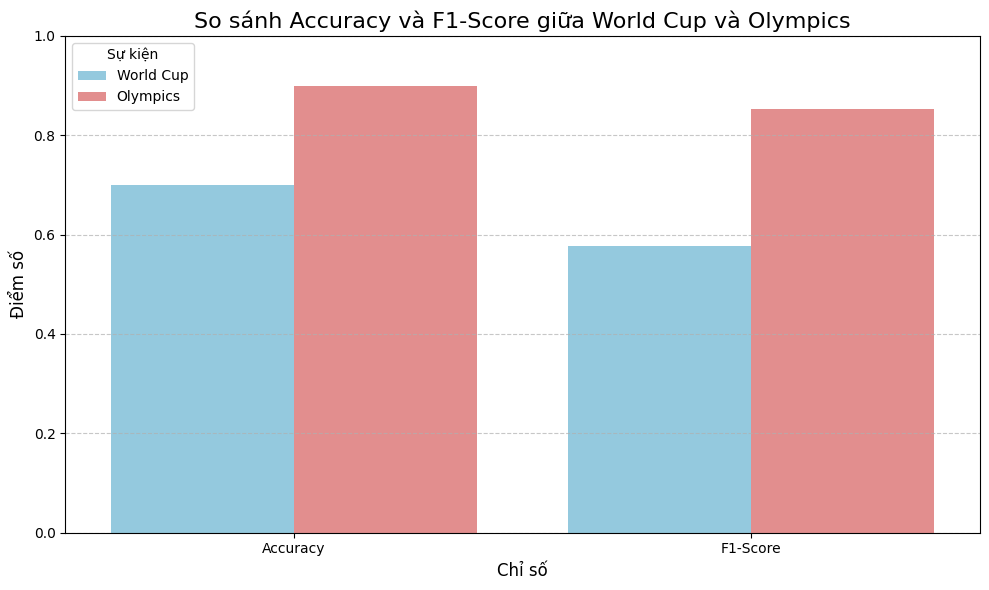

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for the metrics
metrics_data = {
    'Metric': ['Accuracy', 'F1-Score', 'Accuracy', 'F1-Score'],
    'Event': ['World Cup', 'World Cup', 'Olympics', 'Olympics'],
    'Score': [accuracy_wc, f1_wc, accuracy_ol, f1_ol]
}
metrics_df = pd.DataFrame(metrics_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Event', data=metrics_df, palette={'World Cup': 'skyblue', 'Olympics': 'lightcoral'})
plt.title('So sánh Accuracy và F1-Score giữa World Cup và Olympics', fontsize=16)
plt.xlabel('Chỉ số', fontsize=12)
plt.ylabel('Điểm số', fontsize=12)
plt.ylim(0, 1) # Scores are between 0 and 1
plt.legend(title='Sự kiện')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

